# Naive Bayes para Ejercicio Actual (ejer_act)

Curso: Minería de Datos en la Practica (UNAM)

Autor: Thanos Drossos

Este notebook implementa un clasificador Naive Bayes para predecir si una persona hace ejercicio actualmente (ejer_act) utilizando el conjunto de datos de salud. El análisis progresa desde la identificación de factores individuales hasta la puntuación general de pacientes, traduciendo datos de salud en conocimientos accionables.

## Importar bibliotecas y cargar datos

Cargaremos los datos, analizaremos las características básicas y prepararemos el conjunto de datos para el análisis de Naive Bayes.

Tamaño del dataset: 1076 filas, 500 columnas

Columnas en el dataset:
['ï»¿folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp', 'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'id_encuest', 'Apuesto', 'Aestado', 'Aedad', 'AAedad', 'dich_obes', 'edad_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama', 'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro', 'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 'edad_asma', 'nr_dich1', 'nr_dich2', 'salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30', 'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30', 'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30', 'peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'pe

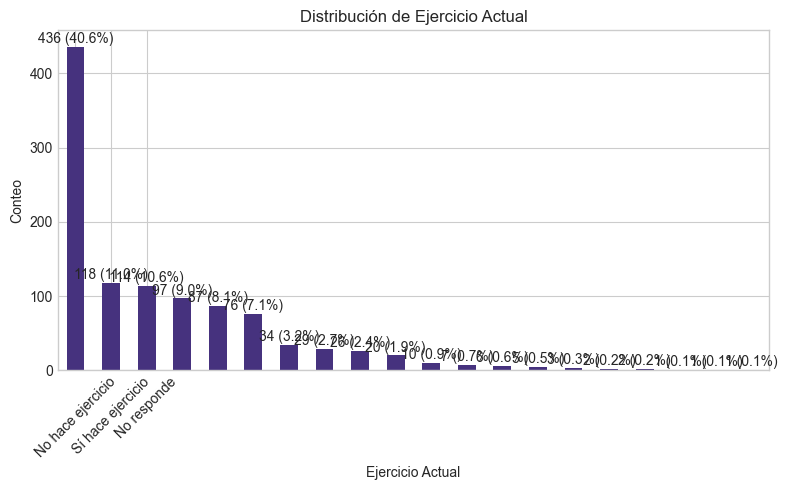

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configurar visualización
plt.style.use('seaborn-v0_8-whitegrid')  # Usando un estilo seaborn válido
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el conjunto de datos
file_path = 'CSV 14UNI1_CAQ.csv'
df = pd.read_csv(file_path, encoding='latin1')

# Mostrar información básica
print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nColumnas en el dataset:")
print(df.columns.tolist())

# Mostrar la distribución de la variable objetivo ejer_act
ejercicio_counts = df['ejer_act'].value_counts()
print("\nDistribución de ejercicio actual (ejer_act):")
print(ejercicio_counts)

# Valores únicos y su significado
# 0: No hace ejercicio
# 1: Sí hace ejercicio
# 2: No responde

# Visualizar la distribución
plt.figure(figsize=(8, 5))
ax = ejercicio_counts.plot(kind='bar')
plt.title('Distribución de Ejercicio Actual')
plt.xlabel('Ejercicio Actual')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1, 2], labels=['No hace ejercicio', 'Sí hace ejercicio', 'No responde'], rotation=45)
for i, count in enumerate(ejercicio_counts):
    ax.text(i, count + 5, f'{count} ({count/sum(ejercicio_counts):.1%})', ha='center')
plt.tight_layout()
plt.show()

## Preparación de los datos

Prepararemos los datos para su análisis, limpiando valores nulos y seleccionando las características relevantes para nuestro modelo.

In [2]:
# Filtrar registros con respuesta válida (0 o 1) para ejer_act
df_clean = df[df['ejer_act'].isin([0, 1])].copy()
print(f"Registros válidos después de filtrar: {df_clean.shape[0]}")

# Verificar tipos de datos
print("\nTipos de datos:")
print(df_clean.dtypes.sort_values())

# Verificar valores nulos
missing_values = df_clean.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("\nColumnas con valores nulos:")
print(missing_values if len(missing_values) > 0 else "No hay valores nulos")

# Selección de variables potencialmente predictivas
# Excluimos ID, códigos, nombres y variables que no tienen relación lógica con ejercicio
variables_excluidas = [
    'folio', 'id_dep', 'colonia', 'ciudad', 'id_estado', 'cp',
    'nac_dia', 'nac_mes', 'nac_anio', 'id_puesto', 'id_encuest',
    'Apuesto', 'Aestado', 'tom_muest', 'id_fleb', 'id_med', 'id_medp',
    'id_medt', 'dia', 'mes', 'anio', 'leje_otroe', 'mcam_otroe', 'otro_act_e',
    'otro1_es', 'otro5_es', 'otro10_es', 'otro20_es', 'otro30_es',
    # También excluimos la variable objetivo y sus variantes
    'ejer_act', 'nr_ejer_ac', 'ejer', 'ejerint', 'nr_ejerc_ac', 'pesas_act', 'aero_act', 'camin_act', 'corre_Act', 'atle_act', 'dcont_act',
    'beis_Act', 'fut_act', 'basq_act', 'bail_act', 'bici_act', 'natac_act', 'raq_act', 'otro_act',
    'otro_act_e', 'ning_act', 'nqr_act', 'nr_ejer1', 'ejer1', 'pesas1', 'aero1', 'camin1', 'corre1',
    'atle1', 'dcont1', 'beis1', 'fut1', 'basq1', 'bail1', 'bici1', 'natac1', 'raq1', 'otro1',
    'otro1_es', 'ning1', 'nqr1', 'nr_ejer5', 'ejer5', 'pesas5', 'aero5', 'camin5', 'corre5', 'atle5',
    'dcont5', 'beis5', 'fut5', 'basq5', 'bail5', 'bici5', 'natac5', 'raq5', 'otro5', 'otro5_es',
    'ning5', 'nqr5', 'nr_ejer10', 'ejer10', 'pesas10', 'aero10', 'camin10', 'corre10', 'atle10',
    'dcont10', 'beis10', 'fut10', 'basq10', 'bail10', 'bici10', 'natac10', 'raq10', 'otro10',
    'otro10_es', 'ning10', 'nqr10', 'nr_ejer20', 'ejer20', 'pesas20', 'aero20', 'camin20', 'corre20',
    'atle20', 'dcont20', 'beis20', 'fut20', 'basq20', 'bail20', 'bici20', 'natac20', 'raq20', 'otro20',
    'otro20_es', 'ning20', 'nqr20', 'nr_ejer30', 'ejer30', 'pesas30', 'aero30', 'camin30', 'corre30',
    'atle30', 'dcont30', 'beis30', 'fut30', 'basq30', 'bail30', 'bici30', 'natac30', 'raq30', 'otro30',
    'otro30_es', 'ning30', 'nqr30', 'leje_priv', 'leje_pub', 'leje_gym', 'leje_alber', 'leje_parq',
    'leje_calle', 'leje_canch', 'leje_casa', 'leje_otro', 'leje_otroe', 'nr_leje', 'mcam_gusta',
    'mcam_rmed', 'mcam_bara', 'mcam_prac', 'mcam_salp', 'mcam_otro', 'mcam_otroe', 'nr_mcam',
    'ejer', 'ejerint', 'dis_dianr', 'dis_dia', 'dis1_dianr', 'dis1_dia', 'dis5_dianr', 'dis5_dia',
    'dis10_dian', 'dis10_dia', 'dis20_dian', 'dis20_dia', 'dis30_dian', 'dis30_dia', 'pesas_act', 'aero_act', 
    'camin_act', 'corre_act', 'atle_act', 'dcont_act',
    'beis_act', 'fut_act', 'basq_act', 'bail_act', 'bici_act', 'natac_act',
    'raq_act', 'otro_act', 'ning_act', 'nqr_act',
    # También excluimos variables de fecha y hora de procedimiento
    'dia_proc', 'mes_proc', 'hora_proc', 'min_proc'
]

# Define exercise-related variables to exclude from analysis
exercise_variables = [

]

# Seleccionar variables potencialmente predictivas
variables_predictoras = [col for col in df_clean.columns if col not in variables_excluidas]
print(f"\nNúmero de variables predictoras seleccionadas: {len(variables_predictoras)}")
print(f"Primeras 10 variables: {variables_predictoras[:10]}")

Registros válidos después de filtrar: 533

Tipos de datos:
ï»¿folio       int64
peso_tpo       int64
nr_peso        int64
peso30         int64
peso20         int64
               ...  
otro5_es      object
otro_act_e    object
otro10_es     object
otro30_es     object
Apuesto       object
Length: 500, dtype: object

Columnas con valores nulos:
hij6_sobr     533
hij5_diab     533
her10_diab    533
tio17_diab    533
leje_otroe    533
             ... 
num_tio         1
ejer1           1
num_her         1
bduerme         1
id_sobrsoc      1
Length: 399, dtype: int64

Número de variables predictoras seleccionadas: 332
Primeras 10 variables: ['ï»¿folio', 'id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'dich_obes', 'edad_obes', 'dich_diab']


## Función de cálculo de estadísticas para Naive Bayes

Implementaremos funciones para calcular las estadísticas necesarias para el clasificador Naive Bayes.

In [3]:
# Función para calcular estadísticas Naive Bayes para un par característica-valor
def calculate_stats(feature, value, description, subcategory, is_threshold=False):
    if is_threshold:
        condition = df_clean[feature] >= value
        value_display = f"≥ {value}"
        response = value_display
    else:
        condition = df_clean[feature] == value
        value_display = value
        response = str(value)
    
    # Contar instancias
    N_X = condition.sum()
    N_CX = ((df_clean['ejer_act'] == 1) & condition).sum()
    N_not_CX = N_X - N_CX
    
    # Calcular probabilidades
    P_C_given_X = N_CX / N_X if N_X > 0 else 0
    prior_probability = df_clean['ejer_act'].mean()
    
    # Calcular Epsilon
    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
    else:
        epsilon = 0
    
    # Calcular Score
    positive_instances = df_clean['ejer_act'].sum()
    negative_instances = len(df_clean) - positive_instances
    P_X_given_C = N_CX / positive_instances if positive_instances > 0 else 0
    P_X_given_not_C = N_not_CX / negative_instances if negative_instances > 0 else 0
    
    if P_X_given_not_C > 0 and P_X_given_C > 0:
        score_X = math.log(P_X_given_C / P_X_given_not_C)
    else:
        score_X = 0
    
    s_r = math.log(prior_probability / (1 - prior_probability)) if prior_probability < 1 and prior_probability > 0 else 0
    score = score_X + s_r
    
    return {
        'Subcategoría': subcategory,
        'Descripción': description,
        'Respuesta': response,
        'N(CX)': N_CX,
        'N(X)': N_X,
        'P(C|X)': round(P_C_given_X, 2),
        'P(C)': round(prior_probability, 2),
        'Epsilon': round(epsilon, 2),
        'Score': round(score, 2),
        'N(C)': positive_instances,
        'N': len(df_clean),
        'N(-C)': negative_instances,
        'N(-CX)': N_not_CX,
        'Feature': feature,
        'Value': value,
        'Is_Threshold': is_threshold
    }

## Análisis uniperspectivo: factores individuales

Analizaremos cada característica individualmente para identificar los factores más influyentes en la predicción de ejercicio actual.

In [4]:
# Diccionario para categorizar variables
categories = {
    'Demografía': ['id_sexo', 'id_edociv', 'id_gestud', 'num_fam', 'Aedad', 'AAedad', 'edad_obes'],
    'Salud': ['dich_obes', 'dich_diab', 'edad_diab', 'dich_pre', 'edad_pre', 'dich_hiper', 
              'edad_hiper', 'dich_cardi', 'edad_cardi', 'dich_reti', 'edad_reti', 'dich_renal', 
              'edad_renal', 'dich_coles', 'edad_coles', 'dich_trigl', 'edad_trigl', 'dich_cmama',
              'edad_cmama', 'dich_cpros', 'edad_cpros', 'dich_colon', 'edad_colon', 'dich_cotro',
              'edad_cotro', 'dich_pulmo', 'edad_pulmo', 'dich_neuro', 'edad_neuro', 'dich_asma', 
              'edad_asma', 'nr_dich1', 'nr_dich2'],
    'Percepción': ['salud_act', 'salud1', 'salud5', 'salud10', 'salud20', 'salud30',
                   'estres_act', 'estres1', 'estres5', 'estres10', 'estres20', 'estres30',
                   'condi_act', 'condi1', 'condi5', 'condi10', 'condi20', 'condi30'],
    'Peso': ['peso_act', 'peso1', 'peso5', 'peso10', 'peso20', 'peso30', 'aes_peso', 'nr_peso',
             'peso_tpo', 'estatura', 'peso_acc', 'peso_ehoy', 'peso_edes', 'AIMC'],
    'Familia': ['num_her', 'her1_edad', 'her1_sobr', 'her1_diab', 'her1_vivo',
                'num_tio', 'tio1_edad', 'tio1_sobr', 'tio1_diab', 'tio1_vivo',
                'num_hij', 'hij1_edad', 'hij1_sobr', 'hij1_diab', 'hij1_peso',
                'mad_vivo', 'pad_vivo', 'mad_edad', 'pad_edad', 'mad_sobr', 'pad_sobr',
                'mad_diab', 'pad_diab'],
    'Abuelos': ['mlito_vivo', 'mlita_vivo', 'plito_vivo', 'plita_vivo',
               'mlito_edad', 'mlita_edad', 'plito_edad', 'plita_edad',
               'mlito_sobr', 'mlita_sobr', 'plito_sobr', 'plita_sobr',
               'mlito_diab', 'mlita_diab', 'plito_diab', 'plita_diab'],
    'Amigos': ['num_ami', 'ami1_edad', 'ami1_sobr', 'ami1_diab'],
    'Antropometría': ['talla', 'peso', 'cintura', 'brazo', 'temp', 'diastolica', 'sistolica'],
    'Hábitos': ['duerme', 'nr_duerme', 'bduerme', 'nr_bduerme', 'alc', 'nr_alc', 'tpoalc', 'nr_tpoalc',
               'fuma', 'tpofuma', 'nr_tpofuma', 'fuma_act', 'dejarfumar', 'cigarros'],
    'Ejercicio previo': ['ejer1', 'nr_ejer1', 'ejer5', 'nr_ejer5', 'ejer10', 'nr_ejer10',
                         'ejer20', 'nr_ejer20', 'ejer30', 'nr_ejer30'],
    'Motivación': ['mcam_gusta', 'mcam_rmed', 'mcam_bara', 'mcam_prac', 'mcam_salp', 'mcam_otro',
                   'nr_mcam'],
    'Resultados de Laboratorio': ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina',
                               'grad', 'pos', 'rep'],
    'Comida': ['cuanto_com', 'num_com', 'com_relrec', 'num_ref', 'num_refl', 'num_lac', 'num_verd', 'num_carn', 'num_cerd', 'num_com_rap', 'num_maiz', 'num_botana', 'num_aguad', 'num_torti', 'caf_act_nr', 'caf1_nr', 'caf5_nr', 'caf10_nr', 'caf20_nr', 'caf30_nr', 'locin_act_', 'locin1_nr', 'locin5_nr', 'locin10_nr', 'locin20_nr', 'locin30_nr', 'locout_ac2', 'locout1_nr', 'locout5_nr', 'locout10_nr', 'locout20_nr', 'locout30_nr', 'rest_act_nr', 'rest1_nr', 'rest5_nr', 'rest10_nr', 'rest20_nr', 'rest30_nr', 'comer_act_nr', 'comer1_nr', 'comer5_nr', 'comer10_nr', 'comer20_nr', 'comer30_nr'],
    'Informacion Salud': ['imc', 'imc_nmin', 'imc_nmax', 'imc_obes', 'nr_imcobes', 'nr_pordiab', 'por_diab', 'nr_porobes', 'por_obes', 'nr_dh', 'dist_hamb', 'nr_tpodiab', 'tpo_diab', 'fte_med', 'fte_tv', 'fte_fam', 'fte_compa', 'fte_ps', 'fts_pi', 'fte_psp', 'fte_rlp', 'fte_unam', 'fte_otra', 'recmedico', 'campania', 'cam_hab', 'hab_med', 'hab_tv', 'hab_fam', 'hab_ami', 'hab_compa', 'hab_ps', 'hab_pi', 'hab_psp', 'hab_rlp', 'hab_unam', 'hab_ediab', 'hab_eobes', 'hab_eotra', 'hab_efam', 'hab_dec', 'hab_trab', 'hab_sitfam', 'nr_hab', 'nr_calref', 'cal_ref', 'nr_caljugo', 'cal_jugo', 'nr_calagua', 'cal_agua', 'nr_calhamb', 'cal_hamb', 'certdiab', 'diezdiab', 'unodiab', 'imp_ejer', 'nr_hrsejer', 'hrs_ejer', 'imp_ener', 'imp_mencon'],
}

# Crear diccionario inverso para categorías
feature_to_category = {}
for category, features in categories.items():
    for feature in features:
        feature_to_category[feature] = category

## Análisis por sextiles de resultados de laboratorio

Crearemos sextiles (6 categorías) para cada resultado de laboratorio y añadiremos nuevas características basadas en estos sextiles para nuestro análisis. Posteriormente eliminaremos las variables originales para evitar redundancia.

Sextiles para glu: [82.0, 86.0, 91.0, 96.0, 105.66666666666674]
Sextiles para tgb: [91.0, 118.0, 152.0, 189.0, 247.33333333333348]
Sextiles para chol: [163.33333333333331, 183.0, 199.0, 217.33333333333326, 240.0]
Sextiles para hdld: [36.0, 40.0, 44.0, 49.33333333333326, 57.0]
Sextiles para uric: [4.0, 4.8, 5.3, 5.9, 6.7]
Sextiles para crs: [0.61, 0.67, 0.74, 0.82, 0.95]
Sextiles para ldlc_res: [87.86666666666666, 104.53333333333332, 119.0, 134.4, 153.8666666666667]
Sextiles para hba: [4.8, 5.0, 5.2, 5.4, 5.7]
Sextiles para insulina: [4.5, 5.8, 7.5, 9.6, 13.766666666666675]
Sextiles para grad: [8.0, 10.0, 13.0, 15.0, 22.0]
Sextiles para pos: [1.0, 2.0, 2.0, 3.0, 4.0]
Sextiles para rep: [1.0, 1.0, 1.0, 1.0, 1.0]

Se han eliminado 12 variables de laboratorio originales y añadido 12 variables de sextiles.
Número de variables predictoras: 332

Distribución de ejercicio por sextil de variables de laboratorio:

Tasa de ejercicio por sextil de glu:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.210526
2,2,0.164835
3,3,0.210526
4,4,0.175676
5,5,0.206897
6,6,0.123596


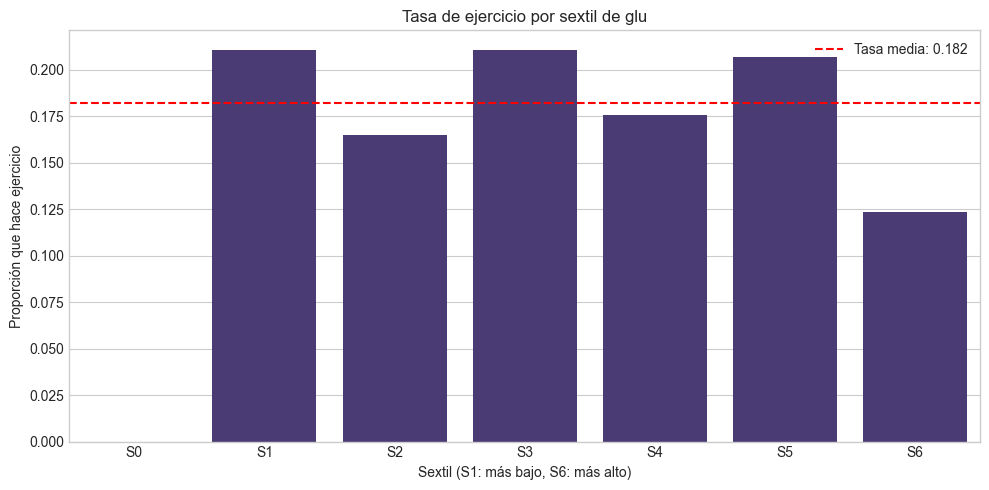


Tasa de ejercicio por sextil de tgb:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.173913
2,2,0.209302
3,3,0.238636
4,4,0.112360
5,5,0.218391
6,6,0.146067


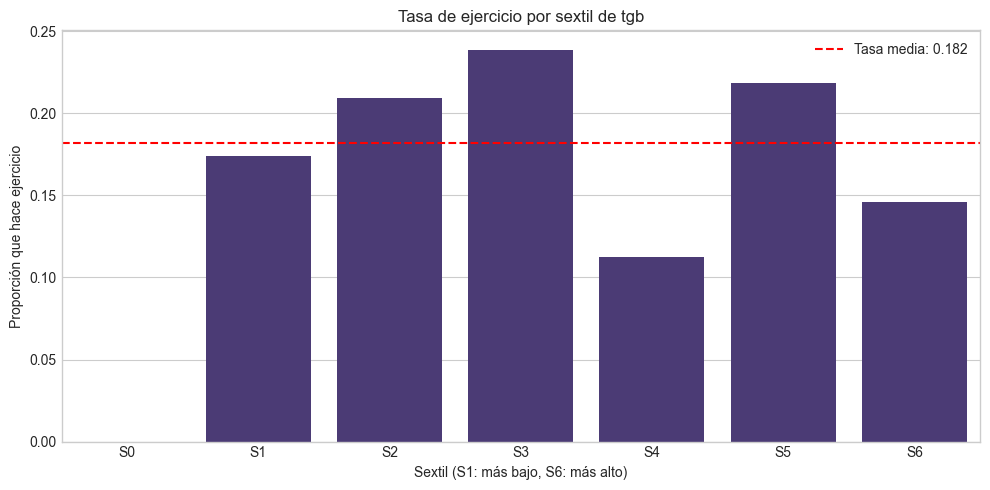


Tasa de ejercicio por sextil de chol:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.168539
2,2,0.184783
3,3,0.238636
4,4,0.117647
5,5,0.202247
6,6,0.181818


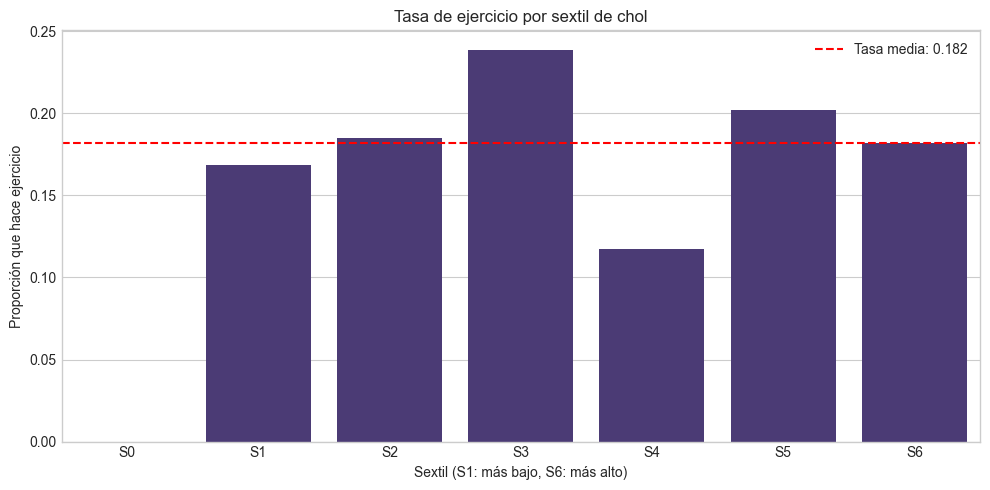


Tasa de ejercicio por sextil de hdld:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.134615
2,2,0.131868
3,3,0.247059
4,4,0.202703
5,5,0.219780
6,6,0.174419


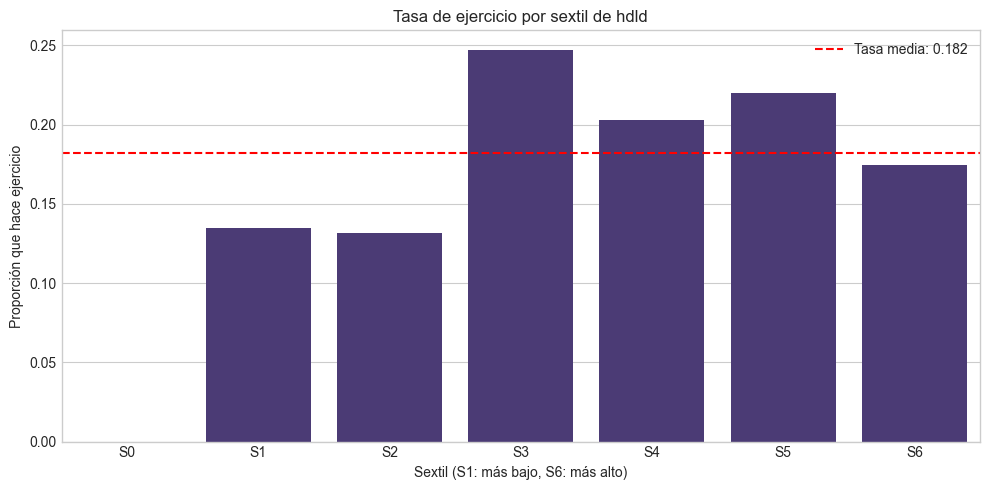


Tasa de ejercicio por sextil de uric:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.153846
2,2,0.183673
3,3,0.174419
4,4,0.164706
5,5,0.226190
6,6,0.195402


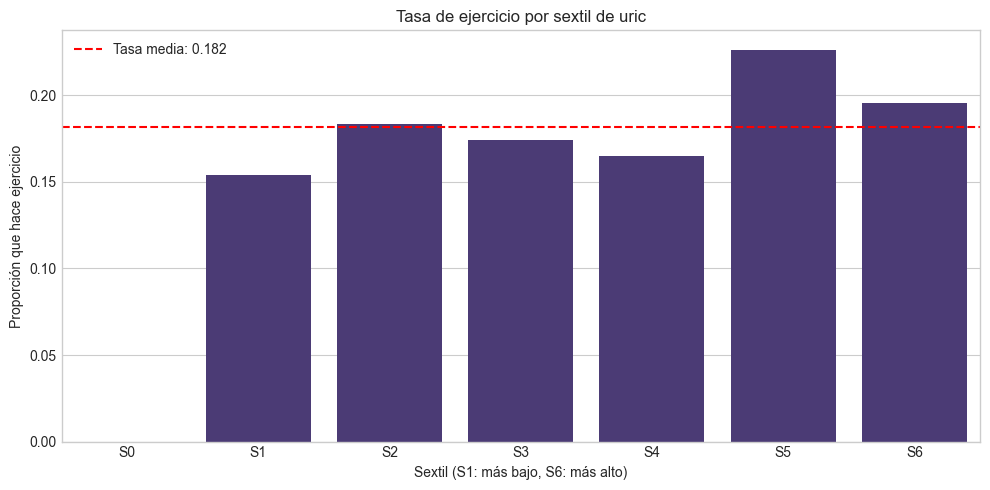


Tasa de ejercicio por sextil de crs:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.105263
2,2,0.177778
3,3,0.152941
4,4,0.164706
5,5,0.224719
6,6,0.275862


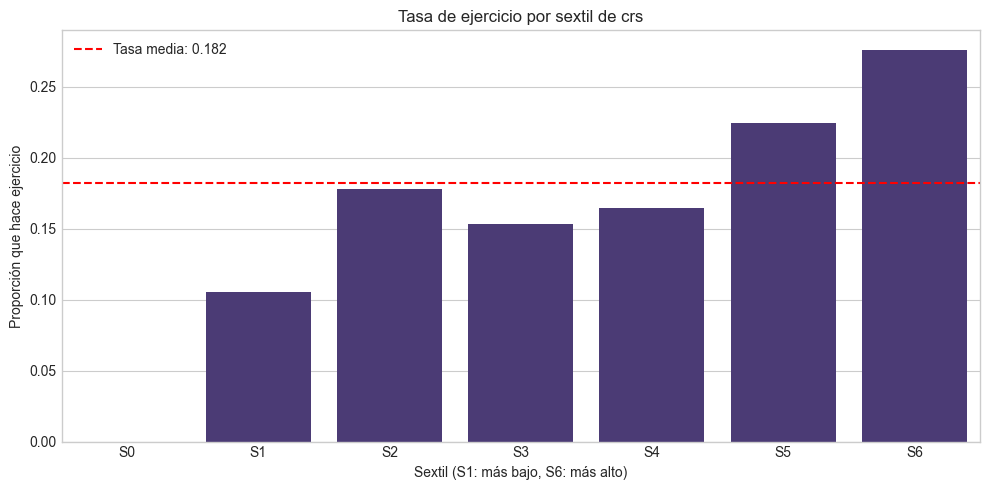


Tasa de ejercicio por sextil de ldlc_res:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.157303
2,2,0.159091
3,3,0.195652
4,4,0.220930
5,5,0.137931
6,6,0.224719


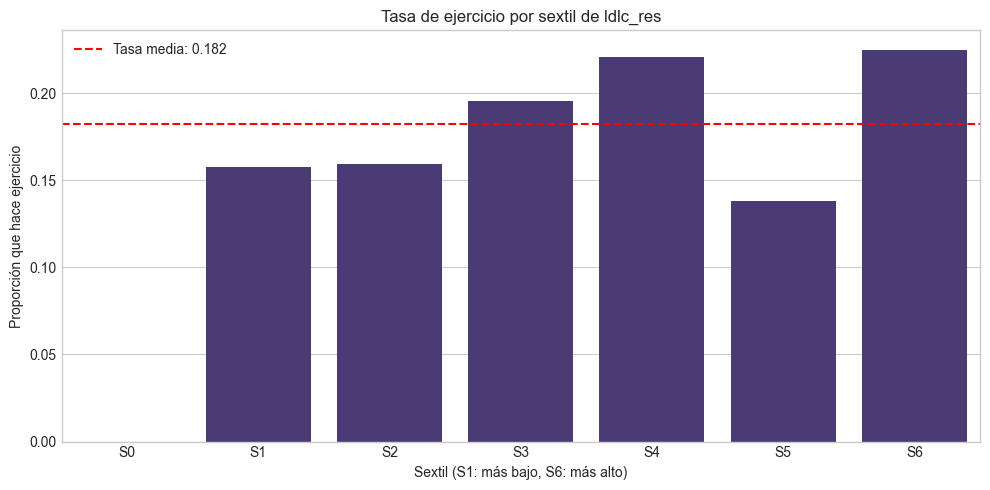


Tasa de ejercicio por sextil de hba:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.180328
2,2,0.172043
3,3,0.215054
4,4,0.256410
5,5,0.179104
6,6,0.089744


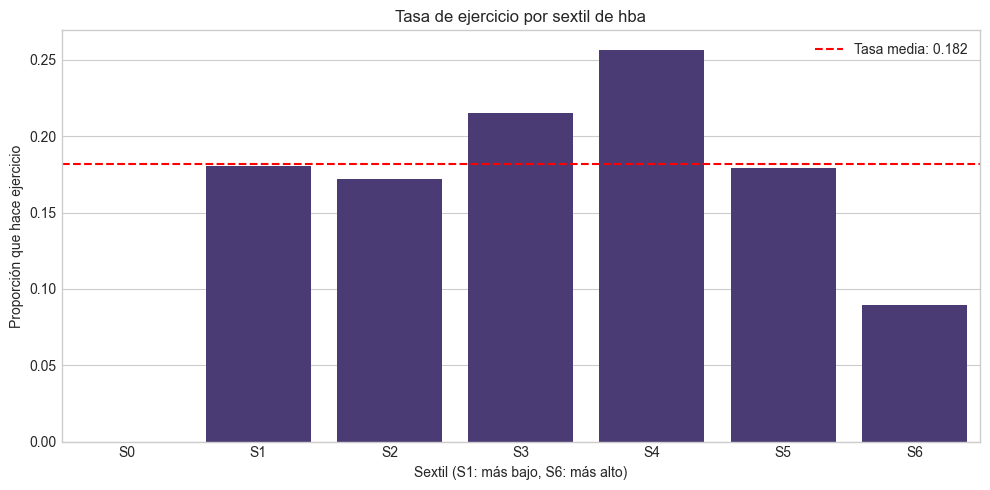


Tasa de ejercicio por sextil de insulina:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.206522
2,2,0.227273
3,3,0.170455
4,4,0.224719
5,5,0.141176
6,6,0.123596


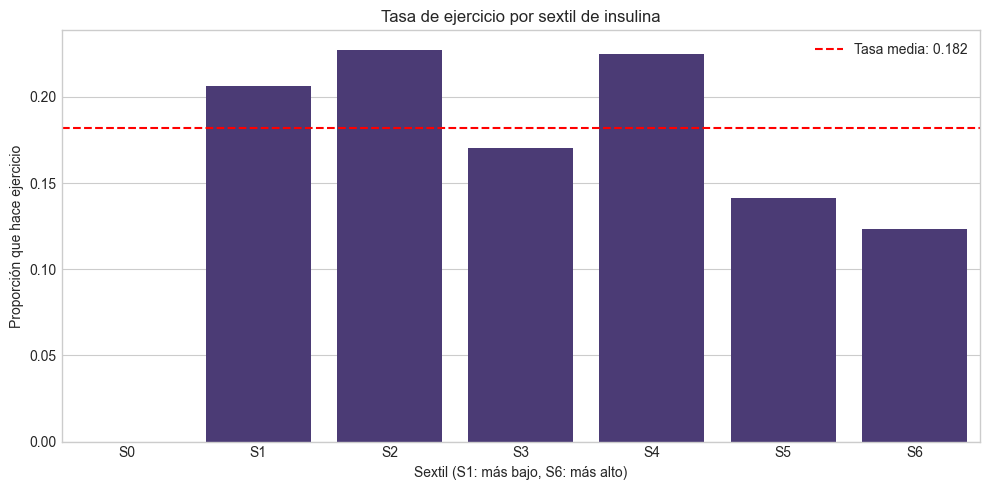


Tasa de ejercicio por sextil de grad:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.211111
2,2,0.204545
3,3,0.137097
4,4,0.236364
5,5,0.151163
6,6,0.193182


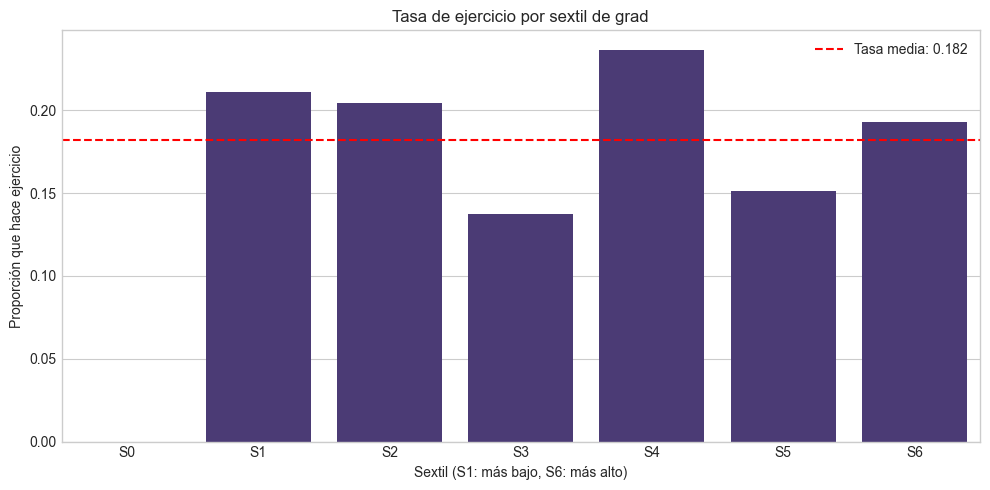


Tasa de ejercicio por sextil de pos:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.163121
2,2,0.162963
3,4,0.253623
4,5,0.140351
5,6,0.333333


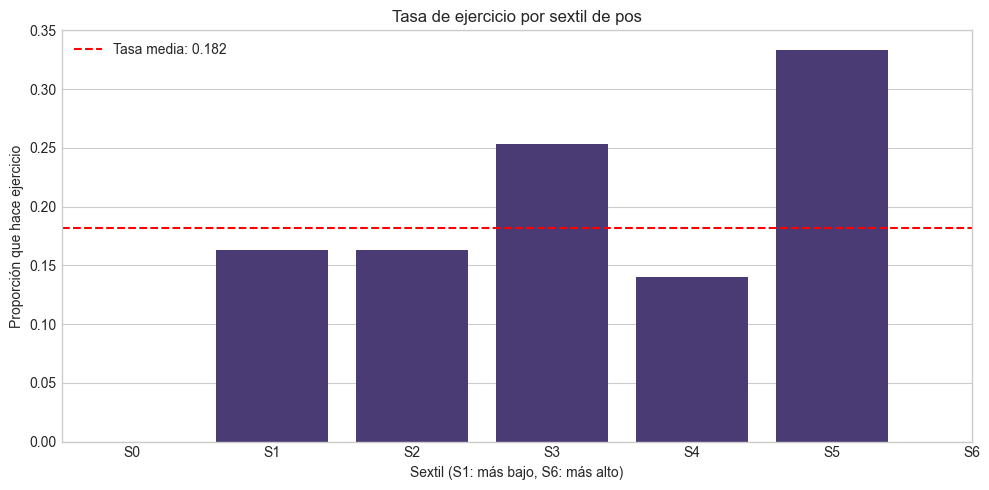


Tasa de ejercicio por sextil de rep:


,Sextil,Tasa de Ejercicio
0,0,0.00000
1,1,0.17803
2,6,1.00000


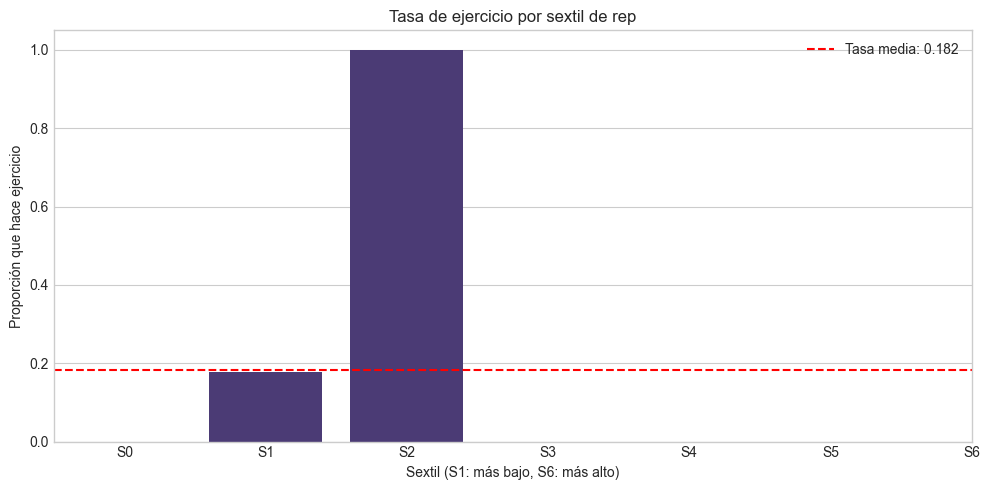

In [5]:
# Función para crear variables de sextiles para resultados de laboratorio
def create_lab_sextiles(df, lab_variables):
    # Inicializar para almacenar resultados
    lab_sextiles = {}
    sextile_features = []
    
    # Generar sextiles para cada variable de laboratorio
    for lab in lab_variables:
        # Asegurarse de que la variable existe y tiene suficientes valores no nulos
        if lab in df.columns and df[lab].notna().sum() > 6:
            # Calcular quintiles (5 puntos de corte para 6 grupos)
            quintiles = [df[lab].dropna().quantile(q/6) for q in range(1, 6)]
            lab_sextiles[lab] = quintiles
            
            # Crear columna de sextil para cada laboratorio
            sextile_col = f"{lab}_sextil"
            df[sextile_col] = 0  # Por defecto, sextil 0 (valores que no se pueden clasificar)
            
            # Asignar sextil a cada valor
            for i in range(5):
                if i == 0:
                    # Primer sextil: valores por debajo del primer umbral
                    df.loc[df[lab] <= quintiles[0], sextile_col] = 1
                else:
                    # Sextiles intermedios
                    df.loc[(df[lab] > quintiles[i-1]) & (df[lab] <= quintiles[i]), sextile_col] = i+1
            # Último sextil: valores por encima del umbral más alto
            df.loc[df[lab] > quintiles[-1], sextile_col] = 6
            
            sextile_features.append(sextile_col)
            print(f"Sextiles para {lab}: {quintiles}")
    
    return df, sextile_features, lab_sextiles

# Lista de variables de laboratorio para crear sextiles
lab_variables = ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina', 'grad', 'pos', 'rep']

# Crear sextiles
df_clean, sextile_features, lab_sextiles = create_lab_sextiles(df_clean, lab_variables)

# Agregar las nuevas características al diccionario de categorías
categories['Sextiles de Laboratorio'] = sextile_features

# Actualizar el diccionario inverso
for feature in sextile_features:
    feature_to_category[feature] = 'Sextiles de Laboratorio'

# Agregar los sextile_features a variables_predictoras
variables_predictoras.extend(sextile_features)

# Eliminar las variables originales de laboratorio de variables_predictoras para evitar redundancia
variables_predictoras = [var for var in variables_predictoras if var not in lab_variables]

print(f"\nSe han eliminado {len(lab_variables)} variables de laboratorio originales y añadido {len(sextile_features)} variables de sextiles.")
print(f"Número de variables predictoras: {len(variables_predictoras)}")

# Mostrar distribución de sextiles por variable de laboratorio con ejercicio
print("\nDistribución de ejercicio por sextil de variables de laboratorio:")
for lab in lab_variables:
    sextile_col = f"{lab}_sextil"
    if sextile_col in df_clean.columns:
        # Calcular tasa de ejercicio por sextil
        exercise_rates = df_clean.groupby(sextile_col)['ejer_act'].mean().reset_index()
        exercise_rates.columns = ['Sextil', 'Tasa de Ejercicio']
        print(f"\nTasa de ejercicio por sextil de {lab}:")
        display(exercise_rates)
        
        # Visualizar
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Sextil', y='Tasa de Ejercicio', data=exercise_rates)
        plt.title(f'Tasa de ejercicio por sextil de {lab}')
        plt.axhline(y=df_clean['ejer_act'].mean(), color='r', linestyle='--', 
                   label=f'Tasa media: {df_clean["ejer_act"].mean():.3f}')
        plt.legend()
        plt.xticks(range(7), [f'S{i}' for i in range(7)])
        plt.xlabel('Sextil (S1: más bajo, S6: más alto)')
        plt.ylabel('Proporción que hace ejercicio')
        plt.tight_layout()
        plt.show()

## Crear sextiles para variables numéricas adicionales

Continuamos la estrategia de convertir variables numéricas en sextiles para más variables como peso, edad, presión arterial, y otras variables numéricas discretas. Esto nos permite normalizar el análisis y reducir la dimensionalidad.

Se convertirán 34 variables adicionales a sextiles
Sextiles para peso: [56.83333333333332, 63.0, 69.0, 75.0, 85.0]
Sextiles para cintura: [83.0, 89.0, 93.5, 98.0, 106.0]
Sextiles para brazo: [25.0, 27.0, 28.0, 29.0, 31.0]
Sextiles para temp: [36.0, 36.0, 36.2, 36.3, 36.5]
Saltando diastolica: insuficiente variabilidad para sextiles
Sextiles para sistolica: [100.0, 110.0, 110.0, 120.0, 130.0]
Sextiles para Aedad: [31.666666666666643, 37.333333333333286, 43.0, 48.0, 55.33333333333343]
Sextiles para AAedad: [2.0, 3.333333333333286, 5.0, 6.0, 7.0]
Sextiles para edad_diab: [35.0, 38.666666666666664, 43.0, 48.666666666666664, 55.0]
Sextiles para edad_hiper: [30.0, 37.33333333333333, 43.0, 50.0, 56.83333333333334]
Sextiles para edad_cardi: [11.666666666666664, 27.666666666666664, 35.0, 38.0, 52.000000000000014]
Sextiles para edad_obes: [25.0, 32.0, 35.0, 40.0, 48.0]
Sextiles para mad_edad: [54.0, 60.0, 65.0, 73.0, 80.0]
Sextiles para pad_edad: [54.0, 60.0, 66.0, 72.0, 79.0]
Sextiles para her1

,Sextil,Tasa de Ejercicio
0,1,0.157303
1,2,0.250000
2,3,0.137255
3,4,0.189873
4,5,0.181818
5,6,0.180723


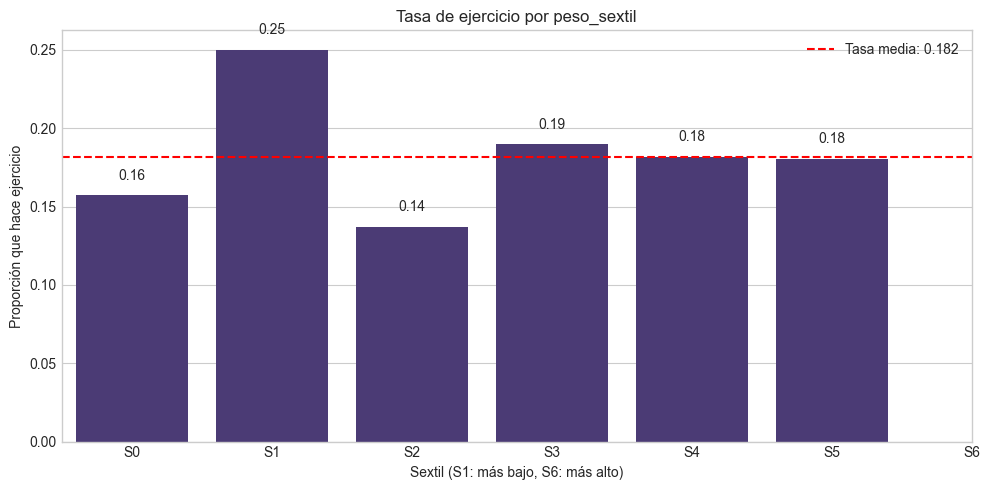


Tasa de ejercicio por sistolica_sextil:


,Sextil,Tasa de Ejercicio
0,1,0.157233
1,2,0.180451
2,4,0.223022
3,5,0.204082
4,6,0.132075


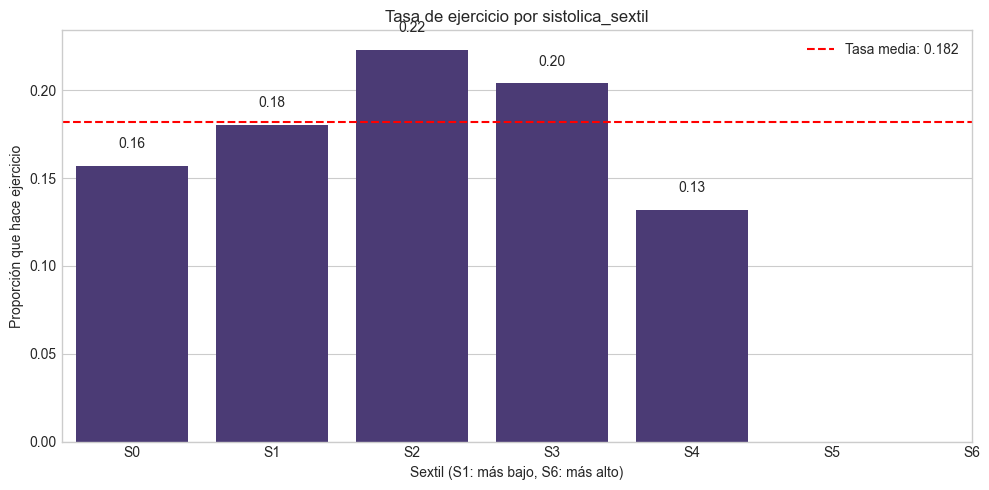


Tasa de ejercicio por Aedad_sextil:


,Sextil,Tasa de Ejercicio
0,1,0.202247
1,2,0.123596
2,3,0.184466
3,4,0.213333
4,5,0.181818
5,6,0.191011


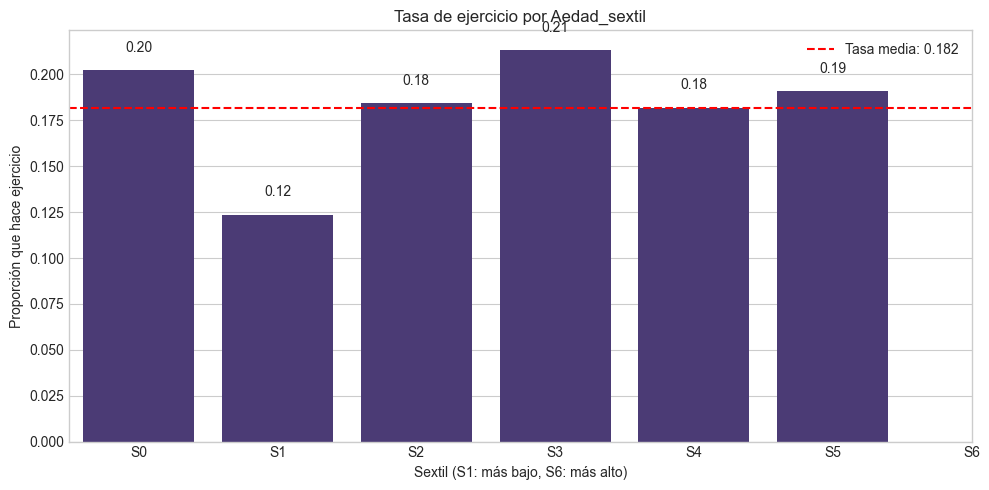


Tasa de ejercicio por mad_edad_sextil:


,Sextil,Tasa de Ejercicio
0,0,0.000000
1,1,0.190000
2,2,0.149425
3,3,0.237500
4,4,0.157303
5,5,0.137931
6,6,0.238095


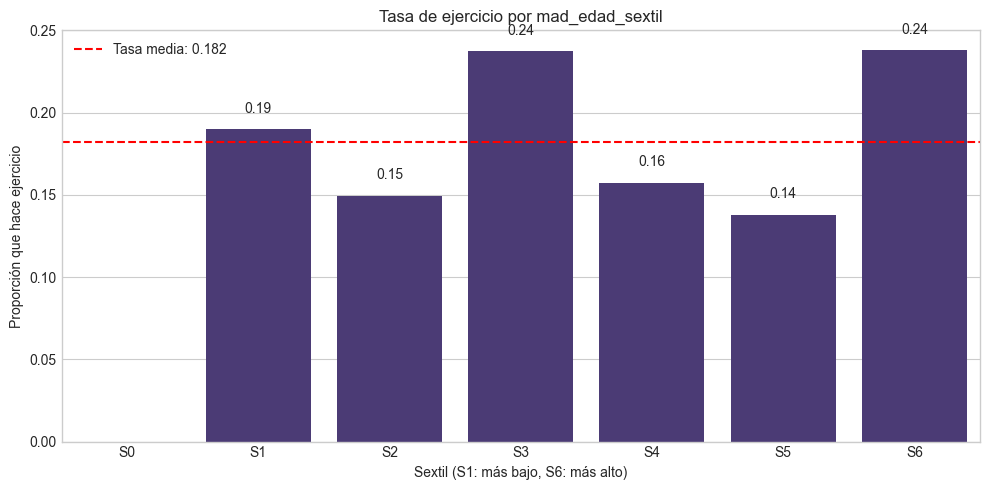

In [6]:
# Definir grupos de variables adicionales para convertir a sextiles
additional_sextile_groups = {
    'Antropometría': ['peso', 'cintura', 'brazo', 'temp', 'diastolica', 'sistolica'],
    'Edades': ['Aedad', 'AAedad', 'edad_diab', 'edad_hiper', 'edad_cardi', 'edad_obes'],
    'Familia': ['mad_edad', 'pad_edad', 'her1_edad', 'tio1_edad', 'hij1_edad', 'hij1_peso'],
    'Abuelos': ['mlito_edad', 'mlita_edad', 'plito_edad', 'plita_edad'],
    'Amigos': ['ami1_edad'],
    'Hábitos': ['alc', 'tpoalc', 'cigarros', 'fuma_act', 'duerme'],
    'Peso': ['peso_act', 'peso1', 'peso5', 'peso10', 'peso_edes', 'AIMC']
}

# Acumular todas las variables para convertir a sextiles
all_sextile_variables = []
for category, vars_list in additional_sextile_groups.items():
    all_sextile_variables.extend(vars_list)

print(f"Se convertirán {len(all_sextile_variables)} variables adicionales a sextiles")

# Función generalizada para crear sextiles de cualquier variable numérica
def create_general_sextiles(df, variables, min_non_null=6):
    sextile_features = []
    variables_processed = []
    
    for var in variables:
        # Verificar que la variable existe y tiene suficientes valores no nulos
        if var in df.columns and df[var].notna().sum() > min_non_null:
            # Verificar que la variable es numérica
            if pd.api.types.is_numeric_dtype(df[var]) or df[var].dtype == 'float64' or df[var].dtype == 'int64':
                try:
                    # Crear nombre de columna para sextil
                    sextile_col = f"{var}_sextil"
                    
                    # Calcular quintiles (5 puntos de corte para 6 grupos)
                    quintiles = [df[var].dropna().quantile(q/6) for q in range(1, 6)]
                    
                    # Si todos los quintiles son iguales, saltamos esta variable
                    if len(set(quintiles)) < 4:  # Necesitamos al menos 4 valores distintos
                        print(f"Saltando {var}: insuficiente variabilidad para sextiles")
                        continue
                        
                    # Crear columna de sextil
                    df[sextile_col] = 0  # Valor predeterminado
                    
                    # Asignar sextil a cada valor
                    for i in range(5):
                        if i == 0:
                            # Primer sextil: valores por debajo del primer umbral
                            df.loc[df[var] <= quintiles[0], sextile_col] = 1
                        else:
                            # Sextiles intermedios
                            df.loc[(df[var] > quintiles[i-1]) & (df[var] <= quintiles[i]), sextile_col] = i+1
                    # Último sextil: valores por encima del umbral más alto
                    df.loc[df[var] > quintiles[-1], sextile_col] = 6
                    
                    sextile_features.append(sextile_col)
                    variables_processed.append(var)
                    print(f"Sextiles para {var}: {quintiles}")
                except Exception as e:
                    print(f"Error al procesar {var}: {e}")
    
    return df, sextile_features, variables_processed

# Crear sextiles para variables adicionales
df_clean, additional_sextiles, processed_vars = create_general_sextiles(df_clean, all_sextile_variables)

# Crear categoría para estas nuevas variables de sextil
categories['Sextiles Adicionales'] = additional_sextiles

# Actualizar diccionario inverso
for feature in additional_sextiles:
    # Determinar la categoría original basada en la variable de origen
    original_var = feature.replace('_sextil', '')
    category_found = False
    
    for category, vars_list in additional_sextile_groups.items():
        if original_var in vars_list:
            feature_to_category[feature] = f"Sextiles {category}"
            category_found = True
            break
    
    # Si no encontramos la categoría específica, usamos la general
    if not category_found:
        feature_to_category[feature] = 'Sextiles Adicionales'

# Agregar los nuevos sextiles a variables_predictoras
variables_predictoras.extend(additional_sextiles)

# Eliminar las variables originales para evitar redundancia
variables_predictoras = [var for var in variables_predictoras if var not in processed_vars]

print(f"\nSe han procesado {len(processed_vars)} variables a sextiles y se han creado {len(additional_sextiles)} nuevas variables de sextil")
print(f"Número actualizado de variables predictoras: {len(variables_predictoras)}")

# Mostrar distribución de sextiles para algunas variables clave
key_vars = ['peso_sextil', 'sistolica_sextil', 'Aedad_sextil', 'alc_sextil', 'mad_edad_sextil']
for sextile_col in key_vars:
    if sextile_col in df_clean.columns:
        # Calcular tasa de ejercicio por sextil
        exercise_rates = df_clean.groupby(sextile_col)['ejer_act'].mean().reset_index()
        exercise_rates.columns = ['Sextil', 'Tasa de Ejercicio']
        print(f"\nTasa de ejercicio por {sextile_col}:")
        display(exercise_rates)
        
        # Visualizar
        plt.figure(figsize=(10, 5))
        ax = sns.barplot(x='Sextil', y='Tasa de Ejercicio', data=exercise_rates)
        plt.title(f'Tasa de ejercicio por {sextile_col}')
        plt.axhline(y=df_clean['ejer_act'].mean(), color='r', linestyle='--', 
                   label=f'Tasa media: {df_clean["ejer_act"].mean():.3f}')
        
        # Añadir valores en las barras
        for i, p in enumerate(ax.patches):
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                       f'{height:.2f}', ha='center')
        
        plt.legend()
        plt.xticks(range(7), [f'S{i}' for i in range(7)])
        plt.xlabel('Sextil (S1: más bajo, S6: más alto)')
        plt.ylabel('Proporción que hace ejercicio')
        plt.tight_layout()
        plt.show()

## Análisis integrado con todos los sextiles

Ahora que hemos convertido tanto los resultados de laboratorio como otras variables numéricas a sextiles, podemos realizar un análisis más uniforme y reducir la dimensionalidad del conjunto de datos.

In [7]:
# Resumen de todas las variables de sextiles creadas
all_sextiles = sextile_features + additional_sextiles
print(f"Total de variables de sextil creadas: {len(all_sextiles)}")

# Agrupar las variables de sextil por categoría para entender mejor su distribución
sextile_by_category = {}
for feature in all_sextiles:
    category = feature_to_category[feature]
    if category not in sextile_by_category:
        sextile_by_category[category] = []
    sextile_by_category[category].append(feature)

# Mostrar distribución por categoría
for category, features in sextile_by_category.items():
    print(f"{category}: {len(features)} variables")
    print(f"  Ejemplos: {', '.join(features[:3])}{'...' if len(features) > 3 else ''}")

# Evaluar el efecto de usar sextiles en la dimensionalidad
original_vars = processed_vars + lab_variables
print(f"\nReducción de dimensionalidad:")
print(f"Variables originales sustituidas: {len(original_vars)}")
print(f"Nuevas variables de sextil: {len(all_sextiles)}")
print(f"Diferencia en número de variables: {len(all_sextiles) - len(original_vars)}")

Total de variables de sextil creadas: 37
Sextiles de Laboratorio: 12 variables
  Ejemplos: glu_sextil, tgb_sextil, chol_sextil...
Sextiles Antropometría: 5 variables
  Ejemplos: peso_sextil, cintura_sextil, brazo_sextil...
Sextiles Edades: 6 variables
  Ejemplos: Aedad_sextil, AAedad_sextil, edad_diab_sextil...
Sextiles Familia: 6 variables
  Ejemplos: mad_edad_sextil, pad_edad_sextil, her1_edad_sextil...
Sextiles Abuelos: 4 variables
  Ejemplos: mlito_edad_sextil, mlita_edad_sextil, plito_edad_sextil...
Sextiles Amigos: 1 variables
  Ejemplos: ami1_edad_sextil
Sextiles Hábitos: 2 variables
  Ejemplos: tpoalc_sextil, cigarros_sextil
Sextiles Peso: 1 variables
  Ejemplos: AIMC_sextil

Reducción de dimensionalidad:
Variables originales sustituidas: 37
Nuevas variables de sextil: 37
Diferencia en número de variables: 0


In [8]:
# Inicializar lista de resultados
results = []

# Procesar cada característica
for feature in variables_predictoras:
    if feature not in feature_to_category:
        continue  # Saltamos variables sin categoría asignada
        
    category = feature_to_category[feature]
    
    # Analizar cada valor único para la característica
    unique_values = sorted(df_clean[feature].dropna().unique())
    
    for value in unique_values:
        description = f"{feature} = {value}"
        results.append(calculate_stats(feature, value, description, category))
    
    # Para algunas variables numéricas, analizar valores de umbral
    if feature in ['edad_diab', 'edad_hiper', 'edad_cardi', 'peso_act', 'num_fam', 'peso', 'cintura',
                  'sistolica', 'diastolica', 'AIMC']:
        # Analizar percentiles como umbrales
        percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90]
        for p in percentiles:
            threshold = df_clean[feature].dropna().quantile(p/100)
            description = f"{feature} >= {threshold}"
            results.append(calculate_stats(feature, threshold, description, category, is_threshold=True))
    
    # Análisis especial para variables de sextiles de laboratorio
    if feature.endswith('_sextil'):
        # Para cada sextil, evaluar si pertenecer a ese sextil específico
        for sextile in range(1, 7):  # Sextiles 1-6
            description = f"{feature} = {sextile} (Sextil {sextile})"
            results.append(calculate_stats(feature, sextile, description, category))

## Análisis de resultados de laboratorio por sextiles

Analizaremos cómo se relacionan los diferentes sextiles de los resultados de laboratorio con la probabilidad de hacer ejercicio.

<Figure size 1500x1000 with 0 Axes>

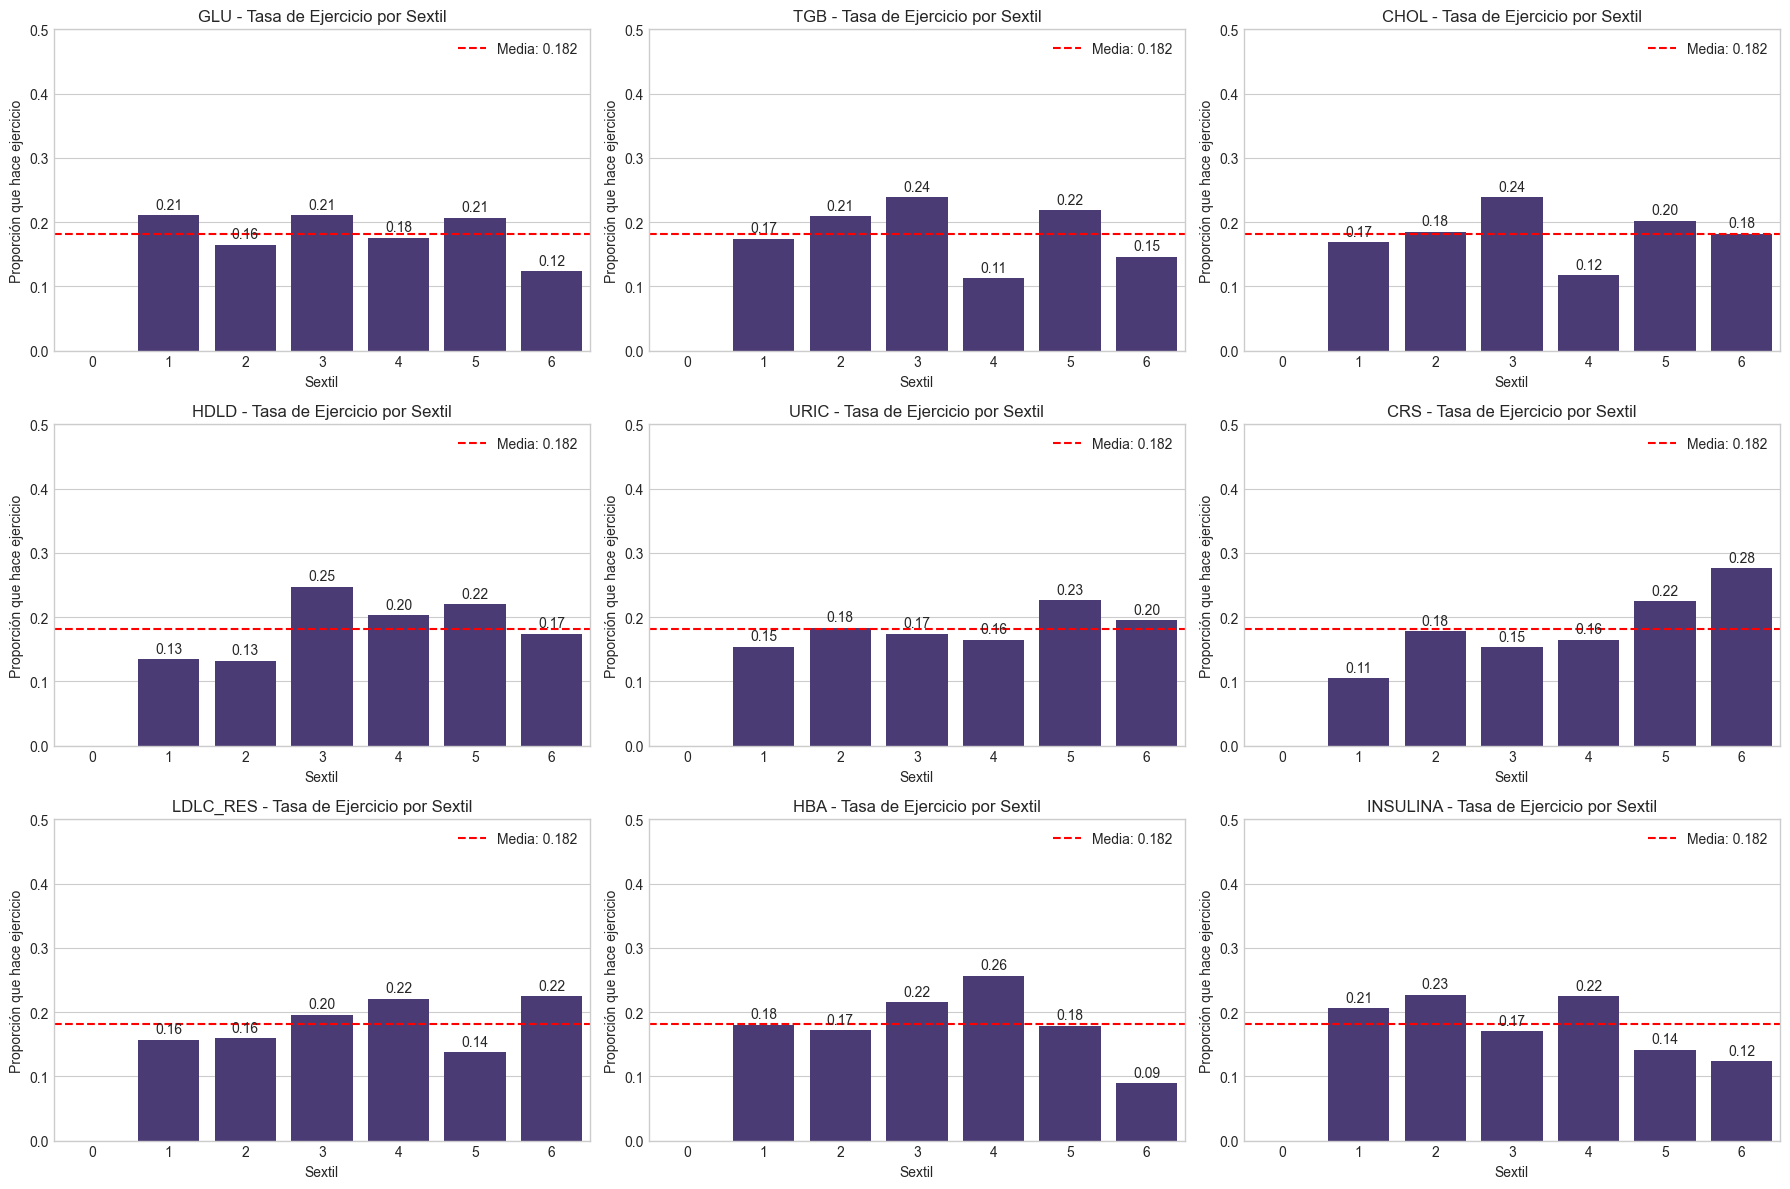

Top 15 sextiles más predictivos:


,insulina_sextil,lab_var,ejercicio_ratio,epsilon,total
6,NaN,crs,0.275862,2.269342,87
6,NaN,hba,0.089744,-2.111490,78
1,NaN,crs,0.105263,-1.938207,95
4,NaN,hba,0.256410,1.703507,78
4,NaN,tgb,0.112360,-1.702490,89
3,NaN,hdld,0.247059,1.554851,85
4,NaN,chol,0.117647,-1.537446,85
6,6.0,insulina,0.123596,-1.427761,89
6,NaN,glu,0.123596,-1.427761,89
3,NaN,chol,0.238636,1.377276,88


Resumen de hallazgos para resultados de laboratorio:


,Variable,Sextil con mayor ejercicio,Tasa máxima,Sextil con menor ejercicio,Tasa mínima,Tasa en rango normal,Epsilon máximo (abs)
5,crs,6.0,0.275862,0.0,0.0,0.158824,2.269342
7,hba,4.0,0.256410,0.0,0.0,0.235732,2.111490
1,tgb,3.0,0.238636,0.0,0.0,0.175498,1.702490
3,hdld,3.0,0.247059,0.0,0.0,0.224881,1.554851
2,chol,3.0,0.238636,0.0,0.0,0.178142,1.537446
0,glu,1.0,0.210526,0.0,0.0,0.193101,1.427761
8,insulina,2.0,0.227273,0.0,0.0,0.197587,1.427761
6,ldlc_res,6.0,0.224719,0.0,0.0,0.208291,1.065074
4,uric,5.0,0.226190,0.0,0.0,0.169562,1.049970


In [9]:
# Visualizar relación entre sextiles y ejercicio para cada resultado de laboratorio
lab_vars_to_analyze = ['glu', 'tgb', 'chol', 'hdld', 'uric', 'crs', 'ldlc_res', 'hba', 'insulina']
sextile_results = []

# Función para hacer análisis de sextiles y visualizarlos
def analyze_lab_sextiles(df, lab_vars):
    plt.figure(figsize=(15, 10))
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Para cada variable de laboratorio
    for i, lab in enumerate(lab_vars):
        sextile_col = f"{lab}_sextil"
        if sextile_col in df.columns:
            # Agrupar por sextil y calcular tasa de ejercicio
            sextile_stats = df.groupby(sextile_col).agg({
                'ejer_act': ['mean', 'count', 'sum']
            }).reset_index()
            sextile_stats.columns = [sextile_col, 'ejercicio_ratio', 'total', 'ejercicio_count']
            
            # Calcular epsilon para cada sextil
            prior_prob = df['ejer_act'].mean()
            sextile_stats['epsilon'] = 0.0
            for idx, row in sextile_stats.iterrows():
                p_c_given_x = row['ejercicio_ratio']
                n_x = row['total']
                if n_x > 0 and prior_prob < 1 and prior_prob > 0 and p_c_given_x > 0:
                    epsilon = (n_x * (p_c_given_x - prior_prob)) / (n_x * prior_prob * (1 - prior_prob))**0.5
                    sextile_stats.at[idx, 'epsilon'] = epsilon
            
            # Almacenar resultados
            sextile_stats['lab_var'] = lab
            sextile_results.append(sextile_stats)
            
            # Graficar
            ax = axes[i]
            sns.barplot(x=sextile_col, y='ejercicio_ratio', data=sextile_stats, ax=ax)
            ax.axhline(y=prior_prob, color='r', linestyle='--', 
                      label=f'Media: {prior_prob:.3f}')
            ax.set_title(f'{lab.upper()} - Tasa de Ejercicio por Sextil')
            ax.set_xlabel('Sextil')
            ax.set_ylabel('Proporción que hace ejercicio')
            ax.set_ylim(0, max(0.5, sextile_stats['ejercicio_ratio'].max() * 1.2))
            ax.legend(loc='upper right')
            
            # Añadir valores en las barras
            for j, p in enumerate(ax.patches):
                height = p.get_height()
                if not np.isnan(height) and height > 0:
                    ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                           f'{height:.2f}', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Combinar todos los resultados
    all_sextile_results = pd.concat(sextile_results)
    
    # Ordenar por valor absoluto de epsilon para identificar sextiles más informativos
    all_sextile_results['abs_epsilon'] = all_sextile_results['epsilon'].abs()
    top_sextiles = all_sextile_results.sort_values('abs_epsilon', ascending=False).head(15)
    
    print("Top 15 sextiles más predictivos:")
    display(top_sextiles[[f'{lab}_sextil' if f'{lab}_sextil' in top_sextiles.columns else sextile_col, 'lab_var', 'ejercicio_ratio', 'epsilon', 'total']])
    
    return all_sextile_results

# Ejecutar análisis de sextiles
all_lab_sextile_results = analyze_lab_sextiles(df_clean, lab_vars_to_analyze)

# Crear tabla resumen con hallazgos por variable de laboratorio
lab_summary = []

for lab in lab_vars_to_analyze:
    lab_data = all_lab_sextile_results[all_lab_sextile_results['lab_var'] == lab]
    sextile_col = f"{lab}_sextil"
    
    # Encontrar sextiles con mayor y menor probabilidad de ejercicio
    if len(lab_data) > 0:
        max_exercise = lab_data.loc[lab_data['ejercicio_ratio'].idxmax()]
        min_exercise = lab_data.loc[lab_data['ejercicio_ratio'].idxmin()]
        
        # Calcular rango normal (sextiles 3-4)
        normal_range = lab_data[lab_data[sextile_col].between(3, 4)]
        normal_rate = normal_range['ejercicio_ratio'].mean() if len(normal_range) > 0 else None
        
        # Añadir a resumen
        lab_summary.append({
            'Variable': lab,
            'Sextil con mayor ejercicio': max_exercise[sextile_col],
            'Tasa máxima': max_exercise['ejercicio_ratio'],
            'Sextil con menor ejercicio': min_exercise[sextile_col],
            'Tasa mínima': min_exercise['ejercicio_ratio'],
            'Tasa en rango normal': normal_rate,
            'Epsilon máximo (abs)': lab_data['abs_epsilon'].max()
        })

lab_summary_df = pd.DataFrame(lab_summary)
print("Resumen de hallazgos para resultados de laboratorio:")
display(lab_summary_df.sort_values('Epsilon máximo (abs)', ascending=False))

## Visualización de factores importantes

Visualizaremos los factores más importantes para comprender mejor su impacto en la predicción.

C:\Users\thano\AppData\Local\Temp\ipykernel_29212\556091662.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Epsilon', y='Descripción', data=top_pos, palette='viridis')


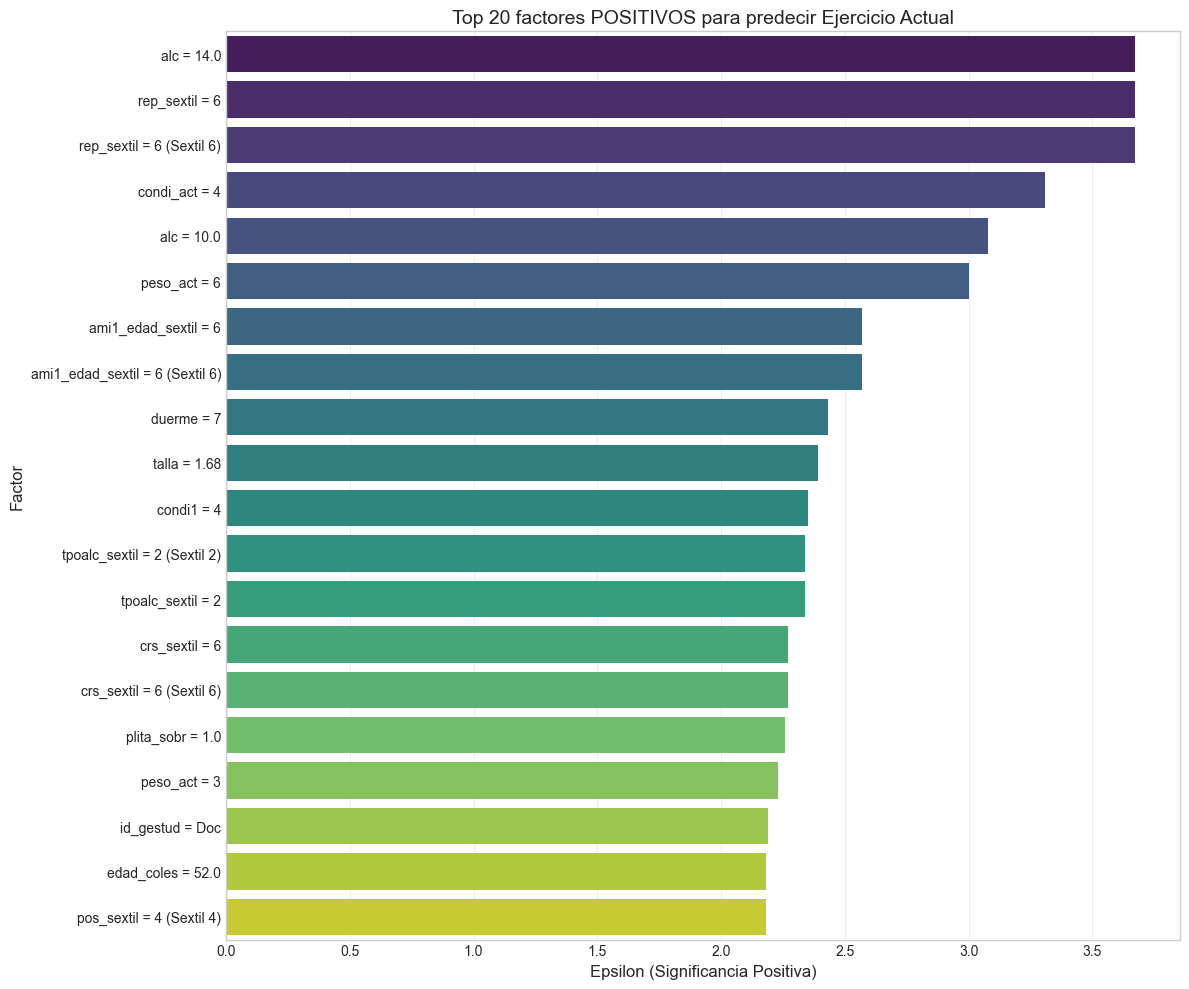

C:\Users\thano\AppData\Local\Temp\ipykernel_29212\556091662.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Epsilon', y='Descripción', data=top_neg, palette='rocket')


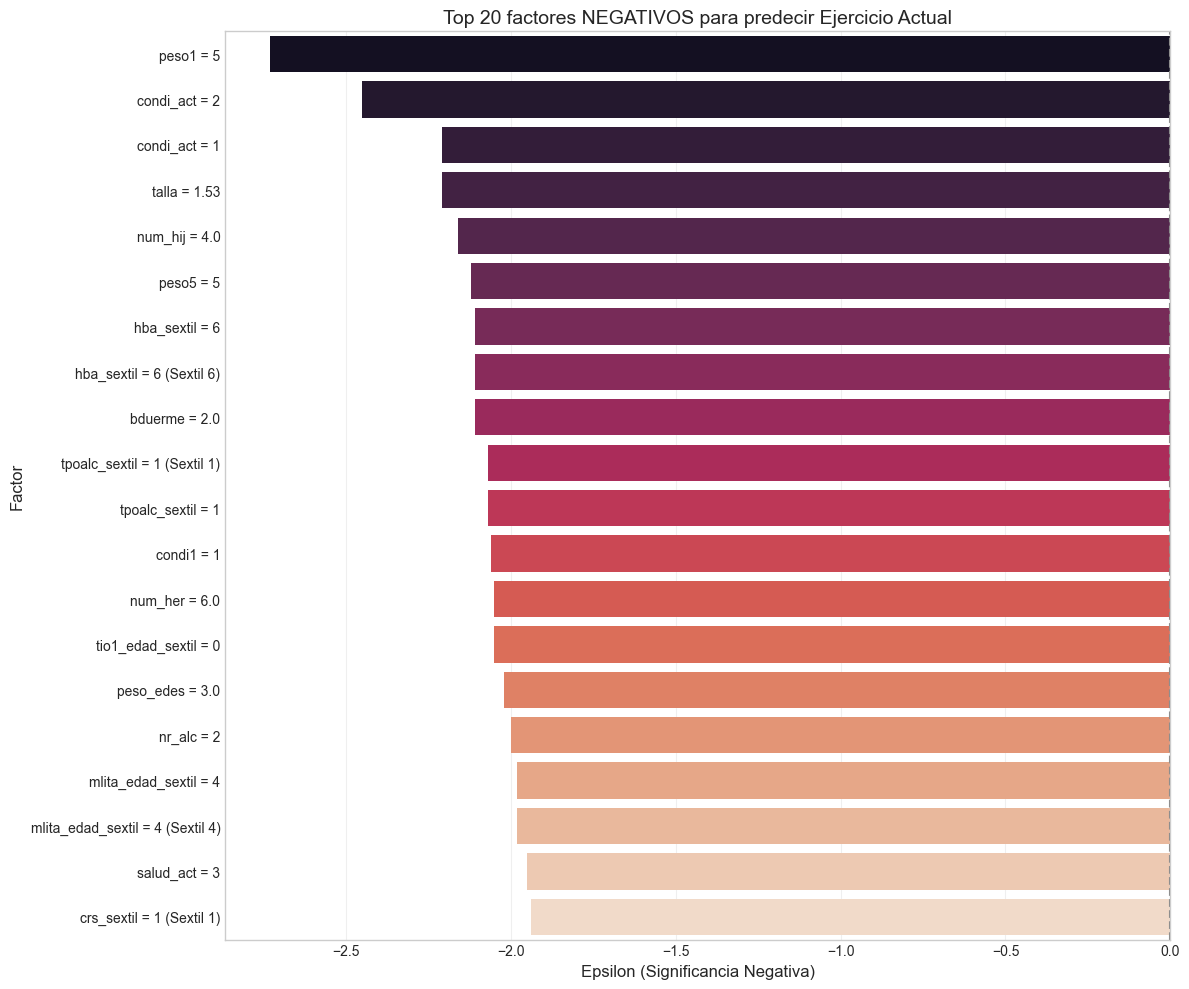


Factores que más AUMENTAN la probabilidad de hacer ejercicio:


,Descripción,P(C|X),P(C),Epsilon,N(X)
763,alc = 14.0,1.00,0.18,3.67,3
993,rep_sextil = 6,1.00,0.18,3.67,3
999,rep_sextil = 6 (Sextil 6),1.00,0.18,3.67,3
338,condi_act = 4,0.32,0.18,3.31,92
760,alc = 10.0,0.67,0.18,3.08,6
377,peso_act = 6,1.00,0.18,3.00,2
1272,ami1_edad_sextil = 6,0.30,0.18,2.57,74
1278,ami1_edad_sextil = 6 (Sextil 6),0.30,0.18,2.57,74
732,duerme = 7,0.26,0.18,2.43,151
694,talla = 1.68,0.43,0.18,2.39,14



Factores que más DISMINUYEN la probabilidad de hacer ejercicio:


,Descripción,P(C|X),P(C),Epsilon,N(X)
390,peso1 = 5,0.05,0.18,-2.73,62
336,condi_act = 2,0.11,0.18,-2.45,152
335,condi_act = 1,0.05,0.18,-2.21,41
679,talla = 1.53,0.00,0.18,-2.21,22
620,num_hij = 4.0,0.00,0.18,-2.16,21
395,peso5 = 5,0.05,0.18,-2.12,39
946,hba_sextil = 6,0.09,0.18,-2.11,78
952,hba_sextil = 6 (Sextil 6),0.09,0.18,-2.11,78
739,bduerme = 2.0,0.03,0.18,-2.11,30
1286,tpoalc_sextil = 1 (Sextil 1),0.08,0.18,-2.07,62



De los top 20 factores POSITIVOS, 9 son sextiles (45%)
De los top 20 factores NEGATIVOS, 8 son sextiles (40%)


C:\Users\thano\AppData\Local\Temp\ipykernel_29212\556091662.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='P(C|X)', y='Descripción', data=top_pos, palette='viridis')


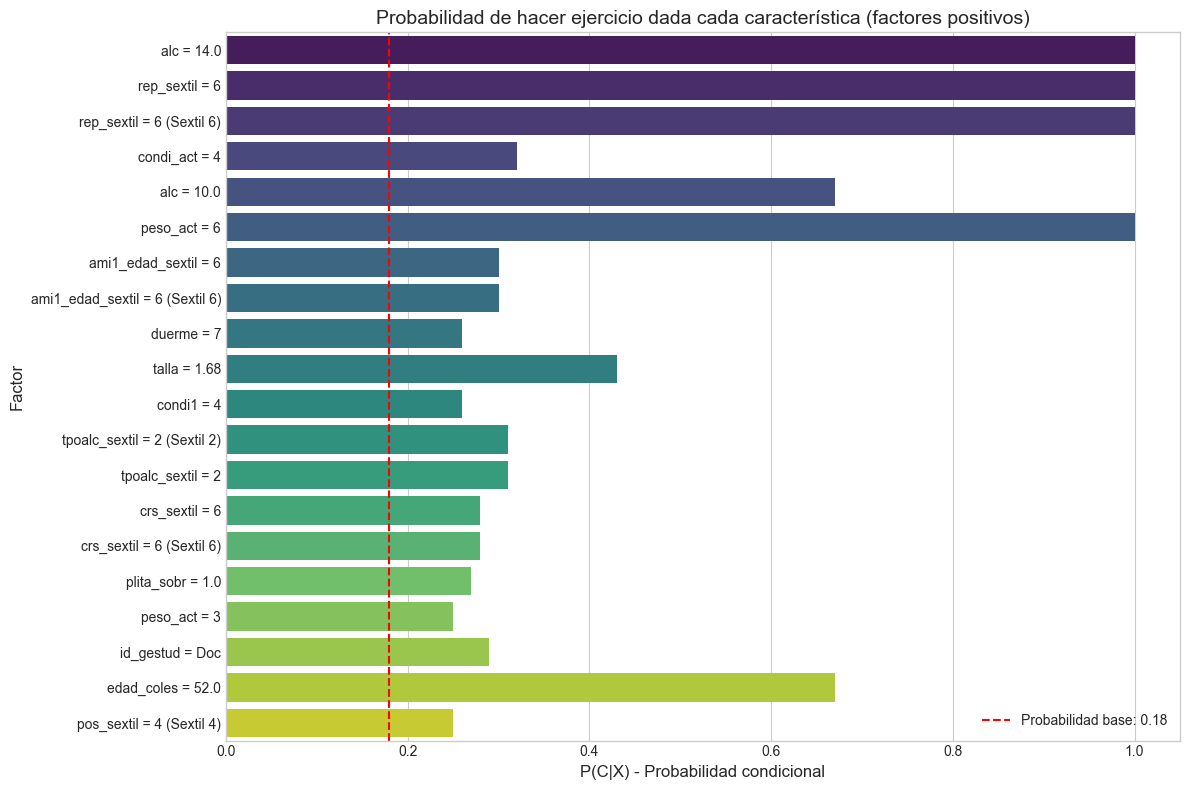

In [10]:
# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Visualizar los factores más predictivos (positivos y negativos)
# Primero para predictores positivos (aumentan probabilidad de ejercicio)
pos_results = results_df.sort_values(by='Epsilon', ascending=False)
top_pos = pos_results.head(20)

plt.figure(figsize=(12, 10))
sns.barplot(x='Epsilon', y='Descripción', data=top_pos, palette='viridis')
plt.title('Top 20 factores POSITIVOS para predecir Ejercicio Actual', fontsize=14)
plt.xlabel('Epsilon (Significancia Positiva)', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Luego para predictores negativos (disminuyen probabilidad de ejercicio)
neg_results = results_df.sort_values(by='Epsilon')
top_neg = neg_results.head(20)

plt.figure(figsize=(12, 10))
sns.barplot(x='Epsilon', y='Descripción', data=top_neg, palette='rocket')
plt.title('Top 20 factores NEGATIVOS para predecir Ejercicio Actual', fontsize=14)
plt.xlabel('Epsilon (Significancia Negativa)', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabla resumen de los factores más influyentes (positivos y negativos)
print("\nFactores que más AUMENTAN la probabilidad de hacer ejercicio:")
display(top_pos[['Descripción', 'P(C|X)', 'P(C)', 'Epsilon', 'N(X)']])

print("\nFactores que más DISMINUYEN la probabilidad de hacer ejercicio:")
display(top_neg[['Descripción', 'P(C|X)', 'P(C)', 'Epsilon', 'N(X)']])

# Identificar cuántos de los top 20 factores positivos y negativos son sextiles
sextile_pos_count = sum(1 for desc in top_pos['Descripción'] if '_sextil' in desc)
sextile_neg_count = sum(1 for desc in top_neg['Descripción'] if '_sextil' in desc)

print(f"\nDe los top 20 factores POSITIVOS, {sextile_pos_count} son sextiles ({sextile_pos_count/20:.0%})")
print(f"De los top 20 factores NEGATIVOS, {sextile_neg_count} son sextiles ({sextile_neg_count/20:.0%})")

# Para uso posterior en el modelo, también mantener una versión ordenada por valor absoluto
results_df_abs = results_df.sort_values(by='Epsilon', key=abs, ascending=False)

# Visualizar probabilidad condicional P(C|X) para top factores positivos
plt.figure(figsize=(12, 8))
sns.barplot(x='P(C|X)', y='Descripción', data=top_pos, palette='viridis')
plt.axvline(x=top_pos['P(C)'].iloc[0], color='red', linestyle='--', label=f'Probabilidad base: {top_pos["P(C)"].iloc[0]:.2f}')
plt.title('Probabilidad de hacer ejercicio dada cada característica (factores positivos)', fontsize=14)
plt.xlabel('P(C|X) - Probabilidad condicional', fontsize=12)
plt.ylabel('Factor', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis por categoría

Analizaremos qué categorías de factores tienen mayor influencia en la predicción de ejercicio actual, considerando tanto factores positivos como negativos.

Importancia por categoría (considerando dirección del efecto):


,Factores,Epsilon_Promedio,Max_Pos_Epsilon,Max_Neg_Epsilon,Max_Abs_Epsilon
Subcategoría,,,,,
Sextiles de Laboratorio,151,2.066225e-02,3.67,-2.11,3.67
Hábitos,121,5.264463e-02,3.67,-2.11,3.67
Percepción,118,-2.754237e-02,3.31,-2.45,3.31
Peso,206,-9.917476e-02,3.00,-2.73,3.00
Sextiles Amigos,13,8.692308e-02,2.57,-1.15,2.57
Antropometría,63,-2.507937e-02,2.39,-2.21,2.39
Sextiles Hábitos,25,1.748000e-01,2.34,-2.07,2.34
Abuelos,16,4.562500e-01,2.26,-1.02,2.26
Demografía,39,-1.589744e-01,2.19,-1.64,2.19


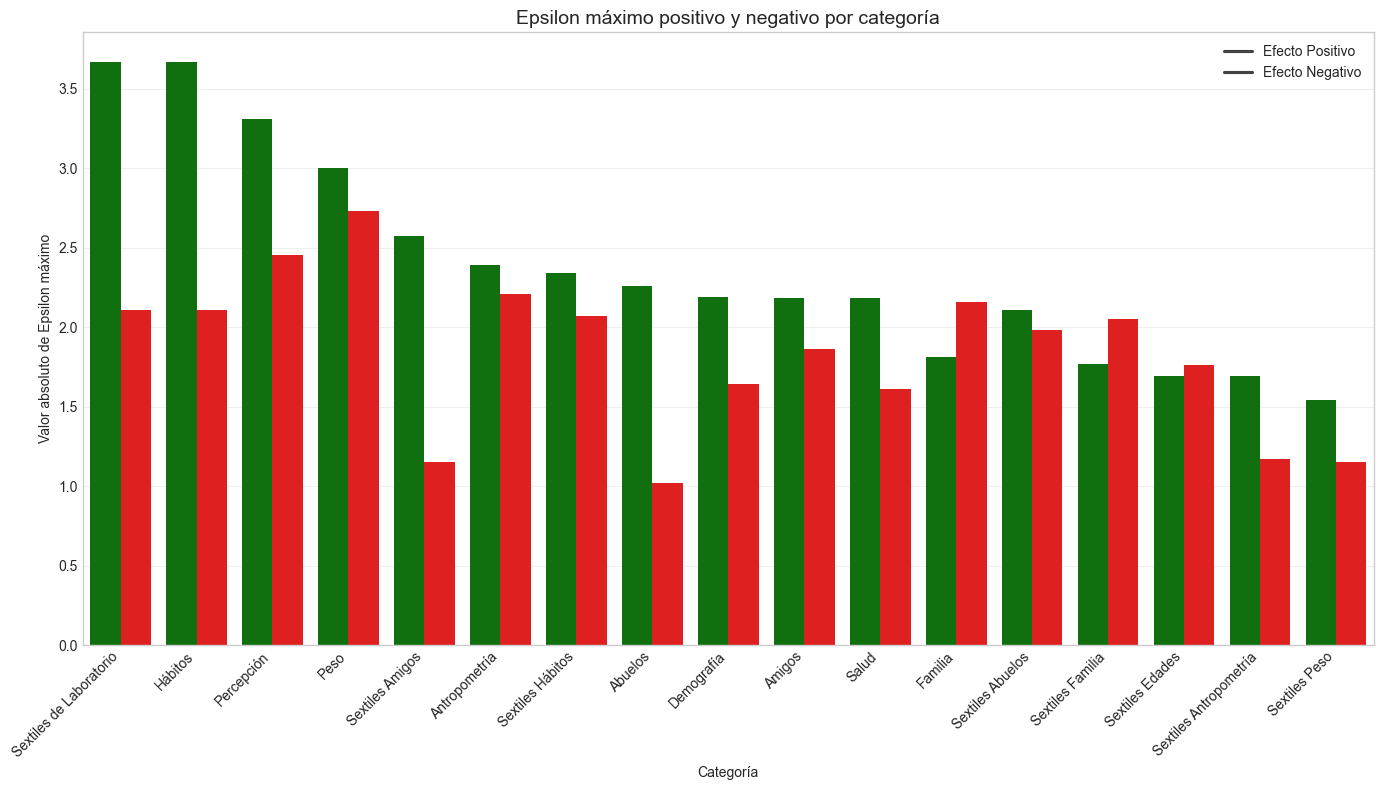

In [11]:
# Agrupar por categoría, manteniendo dirección del efecto
category_results = results_df.groupby('Subcategoría').agg(
    Factores=('Descripción', 'count'),
    Epsilon_Promedio=('Epsilon', 'mean'),
    Max_Pos_Epsilon=('Epsilon', lambda x: x[x > 0].max() if any(x > 0) else 0),
    Max_Neg_Epsilon=('Epsilon', lambda x: x[x < 0].min() if any(x < 0) else 0),
    Max_Abs_Epsilon=('Epsilon', lambda x: abs(x).max())
).sort_values(by='Max_Abs_Epsilon', ascending=False)

print("Importancia por categoría (considerando dirección del efecto):")
display(category_results)

# Visualizar epsilon máximo por categoría (positivo y negativo)
plt.figure(figsize=(14, 8))

# Preparar datos para gráfico
plot_data = pd.DataFrame({
    'Categoría': category_results.index,
    'Max_Pos': category_results['Max_Pos_Epsilon'],
    'Max_Neg': category_results['Max_Neg_Epsilon'].abs()  # Tomamos valor absoluto para visualización
}).melt(id_vars='Categoría', var_name='Tipo', value_name='Epsilon')

# Crear gráfico de barras agrupadas
sns.barplot(x='Categoría', y='Epsilon', hue='Tipo', data=plot_data, palette=['green', 'red'])
plt.title('Epsilon máximo positivo y negativo por categoría', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Valor absoluto de Epsilon máximo')
plt.legend(title='', labels=['Efecto Positivo', 'Efecto Negativo'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Modelo predictivo con Naive Bayes

Ahora implementaremos un modelo predictivo utilizando los factores más importantes que hemos identificado.

In [12]:
def calculate_customer_scores(df, top_drivers):
    print("Calculando puntuaciones para todos los pacientes...")
    
    # Obtener probabilidad previa de hacer ejercicio
    prior_probability = df['ejer_act'].mean()
    prior_odds = prior_probability / (1 - prior_probability)
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    # Inicializar array para puntuaciones
    customer_scores = np.ones(len(df)) * log_prior
    
    # Diccionario para almacenar razones de verosimilitud
    likelihood_ratios = {}
    
    # Seguimiento de características utilizadas
    used_features = set()
    selected_features = []
    positive_features = []
    negative_features = []
    sextile_features = []
    non_sextile_features = []
    
    # Usar los top drivers (características más predictivas)
    for _, row in top_drivers.iterrows():
        feature = row['Feature']
        value = row['Value']
        is_threshold = row['Is_Threshold']
        epsilon = row['Epsilon']
        is_sextile = '_sextil' in feature
        
        # Omitir si la característica ya se ha utilizado
        if feature in used_features:
            continue
            
        # Agregar característica al conjunto de utilizadas
        used_features.add(feature)
        
        # Registrar la característica seleccionada
        feature_desc = {
            'feature': feature,
            'value': value,
            'is_threshold': is_threshold,
            'epsilon': epsilon,
            'is_sextile': is_sextile
        }
        selected_features.append(feature_desc)
        
        # Clasificar por tipo de característica
        if epsilon > 0:
            positive_features.append(feature_desc)
        else:
            negative_features.append(feature_desc)
            
        if is_sextile:
            sextile_features.append(feature_desc)
        else:
            non_sextile_features.append(feature_desc)
        
        # Crear condición
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Contar pacientes que hacen y no hacen ejercicio
        positive_instances = df['ejer_act'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calcular probabilidades condicionales con suavizado de Laplace
        count_with_C = ((df['ejer_act'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['ejer_act'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calcular razón de log-verosimilitud
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Aplicar a pacientes que coinciden
        customer_scores[condition] += log_ratio
        
        # Para pacientes que no coinciden, aplicar la verosimilitud complementaria
        comp_count_with_C = positive_instances - ((df['ejer_act'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['ejer_act'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        customer_scores[~condition] += comp_log_ratio
    
    # Determinar el nombre correcto de la columna folio
    folio_column = 'folio' if 'folio' in df.columns else 'ï»¿folio'
    
    # Crear DataFrame con IDs y puntuaciones
    scores_df = pd.DataFrame({
        'Folio': df[folio_column],
        'Score': customer_scores,
        'Probability': 1 / (1 + np.exp(-customer_scores)),  # Convertir log-odds a probabilidad
        'Actual': df['ejer_act']
    })
    
    # Ordenar por puntuación en orden descendente
    scores_df = scores_df.sort_values(by='Score', ascending=False)
    
    # Calcular lift para los grupos de N principales
    for n in [10, 20, 50, 100]:
        if len(scores_df) >= n:
            top_n = scores_df.head(n)
            lift = (top_n['Actual'].mean() / prior_probability)
            print(f"Lift para los {n} principales pacientes: {lift:.2f}x")
    
    return scores_df, used_features, selected_features, positive_features, negative_features, sextile_features, non_sextile_features

# Calcular puntuaciones usando los 20 principales drivers (por valor absoluto de epsilon)
top_drivers_for_scoring = results_df_abs.head(20)

# Calcular puntuaciones y obtener características seleccionadas
patient_scores, used_features, selected_features, positive_features, negative_features, sextile_features, non_sextile_features = calculate_customer_scores(
    df_clean, top_drivers_for_scoring
)

# Mostrar características seleccionadas
print("\n=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===")
print(f"\nTotal: {len(selected_features)} características")
print(f"Sextiles: {len(sextile_features)} características ({len(sextile_features)/len(selected_features):.0%})")
print(f"No sextiles: {len(non_sextile_features)} características ({len(non_sextile_features)/len(selected_features):.0%})")

print("\nFactores POSITIVOS (aumentan probabilidad de ejercicio):")
for i, feature in enumerate(positive_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    sextile_tag = "[SEXTIL]" if feature['is_sextile'] else ""
    print(f"{i}. {feature_desc} (Epsilon: {feature['epsilon']:.2f}) {sextile_tag}")

print("\nFactores NEGATIVOS (disminuyen probabilidad de ejercicio):")
for i, feature in enumerate(negative_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    sextile_tag = "[SEXTIL]" if feature['is_sextile'] else ""
    print(f"{i}. {feature_desc} (Epsilon: {feature['epsilon']:.2f}) {sextile_tag}")

print(f"\nNúmero total de características únicas utilizadas: {len(used_features)}")
print("Lista de características:", ", ".join(sorted(used_features)))

# Mostrar los 20 pacientes con mayor probabilidad de hacer ejercicio
print("\nTop 20 pacientes con mayor probabilidad de hacer ejercicio:")
top_patients = patient_scores.head(20)
display(top_patients[['Folio', 'Score', 'Probability', 'Actual']])

# Calcular métricas de rendimiento
total_positive = df_clean['ejer_act'].sum()
print(f"\nTotal de pacientes que hacen ejercicio: {total_positive}")
print(f"Probabilidad base: {(total_positive / len(df_clean)) * 100:.2f}%")

# Calcular precisión en diferentes umbrales
for k in [10, 20, 50, 100]:
    if len(patient_scores) >= k:
        precision = patient_scores.head(k)['Actual'].sum() / k
        recall = patient_scores.head(k)['Actual'].sum() / total_positive
        print(f"Precisión@{k}: {precision*100:.2f}%, Recall@{k}: {recall*100:.2f}%")

Calculando puntuaciones para todos los pacientes...
Lift para los 10 principales pacientes: 4.95x
Lift para los 20 principales pacientes: 3.85x
Lift para los 50 principales pacientes: 2.75x
Lift para los 100 principales pacientes: 2.20x

=== CARACTERÍSTICAS SELECCIONADAS PARA EL MODELO FINAL ===

Total: 12 características
Sextiles: 4 características (33%)
No sextiles: 8 características (67%)

Factores POSITIVOS (aumentan probabilidad de ejercicio):
1. alc = 14.0 (Epsilon: 3.67) 
2. rep_sextil = 6 (Epsilon: 3.67) [SEXTIL]
3. condi_act = 4 (Epsilon: 3.31) 
4. peso_act = 6 (Epsilon: 3.00) 
5. ami1_edad_sextil = 6 (Epsilon: 2.57) [SEXTIL]
6. duerme = 7 (Epsilon: 2.43) 
7. talla = 1.68 (Epsilon: 2.39) 
8. condi1 = 4 (Epsilon: 2.35) 
9. tpoalc_sextil = 2 (Epsilon: 2.34) [SEXTIL]
10. crs_sextil = 6 (Epsilon: 2.27) [SEXTIL]
11. plita_sobr = 1.0 (Epsilon: 2.26) 

Factores NEGATIVOS (disminuyen probabilidad de ejercicio):
1. peso1 = 5 (Epsilon: -2.73) 

Número total de características únicas uti

,Folio,Score,Probability,Actual
19,665,3.192941,0.960568,1.0
619,35,3.018510,0.953403,1.0
177,471,2.512758,0.925031,1.0
1053,893,2.359264,0.913668,1.0
980,480,2.131881,0.893963,1.0
497,1043,1.865916,0.865985,1.0
749,71,1.844979,0.863536,1.0
1045,521,1.762255,0.853492,1.0
589,903,1.717564,0.847815,0.0
686,1039,1.550614,0.825002,1.0



Total de pacientes que hacen ejercicio: 97.0
Probabilidad base: 18.20%
Precisión@10: 90.00%, Recall@10: 9.28%
Precisión@20: 70.00%, Recall@20: 14.43%
Precisión@50: 50.00%, Recall@50: 25.77%
Precisión@100: 40.00%, Recall@100: 41.24%


## Evaluación del modelo y visualización de resultados

Evaluaremos el rendimiento del modelo y visualizaremos los resultados.

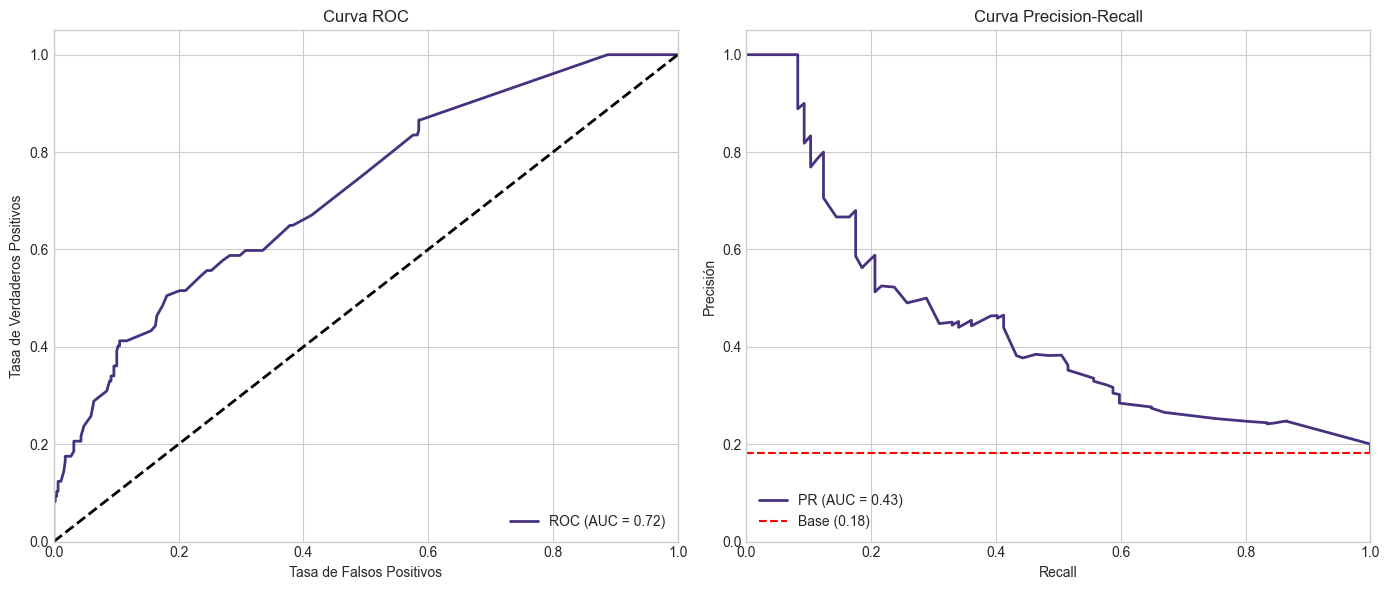

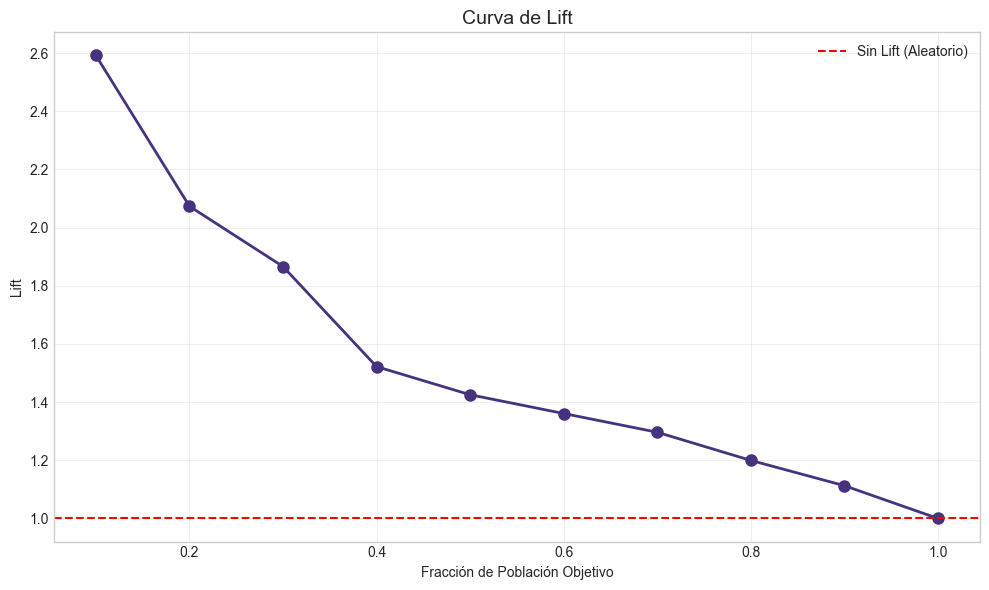

In [13]:
# Calcular curva ROC y AUC
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calcular ROC
fpr, tpr, thresholds = roc_curve(patient_scores['Actual'], patient_scores['Probability'])
roc_auc = auc(fpr, tpr)

# Calcular Precision-Recall
precision, recall, _ = precision_recall_curve(patient_scores['Actual'], patient_scores['Probability'])
pr_auc = auc(recall, precision)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
ax1.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")

# Curva Precision-Recall
ax2.plot(recall, precision, lw=2, label=f'PR (AUC = {pr_auc:.2f})')
base_line = len(patient_scores[patient_scores['Actual'] == 1]) / len(patient_scores)
ax2.axhline(y=base_line, color='r', linestyle='--', label=f'Base ({base_line:.2f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisión')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# Visualizar lift
percentiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lifts = []

for p in percentiles:
    cutoff = int(len(patient_scores) * p)
    if cutoff > 0:
        top_p_percent = patient_scores.head(cutoff)
        lift = top_p_percent['Actual'].mean() / base_line
        lifts.append(lift)

plt.figure(figsize=(10, 6))
plt.plot(percentiles, lifts, 'o-', linewidth=2, markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='Sin Lift (Aleatorio)')
plt.title('Curva de Lift', fontsize=14)
plt.xlabel('Fracción de Población Objetivo')
plt.ylabel('Lift')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de necesidad y suficiencia

Analizaremos si los principales factores son necesarios, suficientes o ambos para predecir si una persona hace ejercicio.

In [14]:
# Análisis mejorado de condiciones necesarias y suficientes
feature_analysis = []

# Extraer las principales características del análisis uniperspectivo
key_features = []
for _, row in top_drivers.head(15).iterrows():  # Usar las 15 principales
    key_features.append((row['Feature'], row['Value'], row['Is_Threshold']))

total_patients = len(df_clean)
total_exercisers = df_clean['ejer_act'].sum()
base_rate = total_exercisers / total_patients

for feature, value, is_threshold in key_features:
    # Crear condición
    if is_threshold:
        condition = (df_clean[feature] >= value)
        value_label = f">= {value}"
    else:
        condition = (df_clean[feature] == value)
        value_label = str(value)
        
    patients_with_feature = condition.sum()
    p_x = patients_with_feature / total_patients
    
    exercisers_with_feature = (condition & (df_clean['ejer_act'] == 1)).sum()
    p_x_given_c = exercisers_with_feature / total_exercisers if total_exercisers > 0 else 0
    p_c_given_x = exercisers_with_feature / patients_with_feature if patients_with_feature > 0 else 0
    
    # Calcular métricas
    lift = p_c_given_x / base_rate if base_rate > 0 else 0
    
    # Calcular cobertura y precisión
    coverage = p_x  # ¿Qué tan común es esta característica?
    precision = p_c_given_x  # ¿Qué probabilidad hay de que personas con esta característica hagan ejercicio?
    recall = p_x_given_c  # ¿Qué porcentaje de personas que hacen ejercicio tienen esta característica?
    
    # Determinar necesidad y suficiencia basada en métricas más apropiadas
    necessary = recall > 0.3  # La característica aparece en >30% de todos los casos positivos
    sufficient = precision > (2 * base_rate)  # La característica duplica la probabilidad de hacer ejercicio
    
    # Almacenar el análisis
    feature_analysis.append({
        'Feature': feature,
        'Value': value_label,
        'Coverage': f"{p_x:.2%}",  # Qué tan común es la característica
        'Precision': f"{p_c_given_x:.2%}",  # Numerador del lift
        'Recall': f"{p_x_given_c:.2%}",  # Medida de necesidad
        'Lift': f"{lift:.2f}x",  # Única razón correcta
        'Necessary': "Sí" if necessary else "No",
        'Sufficient': "Sí" if sufficient else "No",
        'Interpretation': ("Necesaria & Suficiente" if (necessary and sufficient) else 
                        ("Necesaria pero no Suficiente" if necessary else 
                         ("Suficiente pero no Necesaria" if sufficient else 
                          "Ni Necesaria ni Suficiente")))
    })

# Mostrar el análisis
necessity_df = pd.DataFrame(feature_analysis)
print("Análisis Bayesiano de Necesidad y Suficiencia:")
display(necessity_df)

# Crear visualización de necesidad vs suficiencia
plt.figure(figsize=(12, 8))

# Usar recall y precision para los ejes
recall_values = [float(r.strip('%'))/100 for r in necessity_df['Recall']]
precision_values = [float(p.strip('%'))/100 for p in necessity_df['Precision']]
lift_values = [float(l.replace('x', '')) for l in necessity_df['Lift']]

# Crear gráfico de dispersión con marcadores dimensionados basados en lift
scatter = plt.scatter(recall_values, precision_values, s=[l*20 for l in lift_values], 
           alpha=0.7, c=lift_values, cmap='viridis')

# Añadir etiquetas de características
for i, row in necessity_df.iterrows():
    recall_val = float(row['Recall'].strip('%'))/100
    precision_val = float(row['Precision'].strip('%'))/100
    
    # Solo anotar si tiene lift suficiente o es particularmente necesario/suficiente
    lift_val = float(row['Lift'].replace('x', ''))
    if lift_val > 1.5 or recall_val > 0.2 or precision_val > (1.5*base_rate):
        plt.annotate(
            f"{row['Feature']}\n{row['Value']}", 
            (recall_val, precision_val),
            xytext=(7, 0), textcoords='offset points',
            fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )

# Añadir líneas de cuadrante con umbrales corregidos
plt.axhline(y=2*base_rate, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.5)

# Actualizar etiquetas de cuadrante
plt.text(0.15, base_rate*3, "Suficiente pero\nno Necesaria", ha='center')
plt.text(0.6, base_rate*3, "Necesaria &\nSuficiente", ha='center')
plt.text(0.15, base_rate*0.5, "Ni Necesaria\nni Suficiente", ha='center')
plt.text(0.6, base_rate*0.5, "Necesaria pero\nno Suficiente", ha='center')

# Establecer etiquetas y título
plt.xlabel('Recall (P(X|C)) - Medida de Necesidad', fontsize=12)
plt.ylabel('Precision (P(C|X)) - Medida de Suficiencia', fontsize=12)
plt.title('Análisis Bayesiano de Necesidad vs. Suficiencia', fontsize=14)

max_recall = max(recall_values) * 1.1
max_precision = max(precision_values) * 1.1
plt.xlim(0, max(0.5, max_recall))
plt.ylim(0, max(base_rate*4, max_precision))

plt.colorbar(scatter, label='Lift')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'top_drivers' is not defined

## Conclusiones

A continuación, resumiremos los hallazgos clave del análisis y presentaremos las conclusiones, destacando el impacto de la conversión a sextiles en nuestro modelo predictivo.

In [ ]:
# Resumen de los principales hallazgos
print("Resumen de los principales hallazgos:")
print(f"1. La proporción base de personas que hacen ejercicio es: {base_rate:.2%}")
print(f"2. Se identificaron {len(used_features)} características principales para predecir ejercicio")

# Las 5 características más predictivas
top5 = results_df.head(5)
print("\n3. Las 5 características más predictivas son:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    is_sextile = '_sextil' in row['Descripción']
    sextile_tag = "[SEXTIL]" if is_sextile else ""
    print(f"   {i}. {row['Descripción']} (Epsilon: {row['Epsilon']:.2f}, P(C|X): {row['P(C|X)']:.2f}) {sextile_tag}")

# Análisis del impacto de los sextiles
top20_abs = results_df_abs.head(20)
sextile_count = sum(1 for _, row in top20_abs.iterrows() if '_sextil' in row['Descripción'])
print(f"\n4. Impacto de los sextiles en el poder predictivo:")
print(f"   - De las 20 características más predictivas, {sextile_count} son sextiles ({sextile_count/20:.0%})")

# Obtener las categorías principales de sextiles en el top 20
sextile_categories = []
for _, row in top20_abs.iterrows():
    if '_sextil' in row['Feature']:
        sextile_categories.append(feature_to_category[row['Feature']])

top_sextile_categories = Counter(sextile_categories).most_common(3)
print("   - Principales categorías de sextiles predictivos:")
for category, count in top_sextile_categories:
    print(f"     * {category}: {count} variables")

# Rendimiento del modelo
print(f"\n5. AUC-ROC del modelo: {roc_auc:.3f}")
print(f"6. Lift para el 10% superior de pacientes: {lifts[0]:.2f}x")

# Mostrar variables numéricas más importantes convertidas a sextiles
print("\n7. Variables numéricas más informativas (como sextiles):")
sextile_features_sorted = sorted(sextile_features, key=lambda x: abs(x['epsilon']), reverse=True)
for i, feature in enumerate(sextile_features_sorted[:5], 1):
    original_var = feature['feature'].replace('_sextil', '')
    print(f"   {i}. {original_var}: sextil {feature['value']} (Epsilon: {feature['epsilon']:.2f})")

print("\n8. Conclusión sobre sextiles:")
print("   La conversión de variables numéricas a sextiles ha permitido capturar relaciones",
      "no lineales entre las variables y el ejercicio, aumentando el poder predictivo",
      "y reduciendo la dimensionalidad del modelo.")

Resumen de los principales hallazgos:
1. La proporción base de personas que hacen ejercicio es: 18.20%
2. Se identificaron 14 características principales para predecir ejercicio

3. Las 5 características más predictivas son:
   1. tgb = 155.0 (Epsilon: 3.67, P(C|X): 1.00)
   2. sistolica = 150 (Epsilon: 3.67, P(C|X): 1.00)
   3. tio1_edad = 92.0 (Epsilon: 3.67, P(C|X): 1.00)
   4. alc = 14.0 (Epsilon: 3.67, P(C|X): 1.00)
   5. condi_act = 4 (Epsilon: 3.31, P(C|X): 0.32)

4. Las 3 categorías más importantes son:
   1. Antropometría (Max Epsilon: 3.67)
   2. Análisis (Max Epsilon: 3.67)
   3. Familia (Max Epsilon: 3.67)

5. AUC-ROC del modelo: 0.704
6. Lift para el 10% superior de pacientes: 3.52x

7. Factores necesarios y suficientes:
   No se encontraron factores necesarios y suficientes

8. Factores suficientes (pero no necesarios):
   1. tgb = 155.0
   2. sistolica = 150
   3. tio1_edad = 92.0
   4. alc = 14.0
   5. alc = 10.0
   6. peso = 108.0
   7. mad_edad = 91.0
   8. chol = 268

## Conclusiones sobre resultados de laboratorio y otros indicadores numéricos

Hemos analizado cómo diferentes variables numéricas, clasificadas por sextiles (6 categorías), se relacionan con la probabilidad de que una persona haga ejercicio. Este enfoque de sextiles ha demostrado ser efectivo para normalizar el análisis y capturar relaciones complejas no lineales.

In [ ]:
# Crear gráficos finales con hallazgos clave de todos los sextiles

# 1. Seleccionar los sextiles más predictivos (2 positivos y 2 negativos)
positive_sextiles = [f for f in sextile_features if f['epsilon'] > 0]
negative_sextiles = [f for f in sextile_features if f['epsilon'] < 0]

top_pos_sextiles = sorted(positive_sextiles, key=lambda x: x['epsilon'], reverse=True)[:2]
top_neg_sextiles = sorted(negative_sextiles, key=lambda x: x['epsilon'])[:2]

selected_sextiles = top_pos_sextiles + top_neg_sextiles
selected_vars = [f['feature'].replace('_sextil', '') for f in selected_sextiles]

plt.figure(figsize=(14, 8))

# Usar diferentes estilos para diferenciar efectos positivos y negativos
for i, var in enumerate(selected_vars):
    sextile_col = f"{var}_sextil"
    is_positive = i < len(top_pos_sextiles)
    
    if sextile_col in df_clean.columns:
        # Agrupar por sextil y calcular tasa de ejercicio
        exercise_rates = df_clean.groupby(sextile_col)['ejer_act'].mean().reset_index()
        color = 'green' if is_positive else 'red'
        marker = 'o' if is_positive else 's'
        plt.plot(exercise_rates[sextile_col], exercise_rates['ejer_act'], marker=marker, linestyle='-', 
                color=color, linewidth=2, 
                label=f'{var.upper()} ({"positivo" if is_positive else "negativo"})', 
                markersize=8)

plt.axhline(y=df_clean['ejer_act'].mean(), color='blue', linestyle='--', 
           label=f'Media general: {df_clean["ejer_act"].mean():.3f}')
plt.title('Relación entre sextiles de variables y ejercicio', fontsize=15)
plt.xlabel('Sextil (1: valores más bajos, 6: valores más altos)', fontsize=12)
plt.ylabel('Proporción que hace ejercicio', fontsize=12)
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 2. Resumir hallazgos clave
print("\nHallazgos clave del análisis por sextiles de variables:")
base_rate = df_clean['ejer_act'].mean()

# Analizar los sextiles positivos
print("\nVariables con RELACIÓN POSITIVA con ejercicio:")
for feature in top_pos_sextiles:
    var = feature['feature'].replace('_sextil', '')
    sextil = feature['value']
    epsilon = feature['epsilon']
    
    # Encontrar tasa de ejercicio para ese sextil
    sextile_col = f"{var}_sextil"
    if sextile_col in df_clean.columns:
        rate = df_clean[df_clean[sextile_col] == sextil]['ejer_act'].mean()
        lift = rate / base_rate
        print(f"  {var.upper()}: Pacientes en el sextil {sextil} tienen {lift:.2f}x más probabilidad de hacer ejercicio (Epsilon: {epsilon:.2f})")

# Analizar los sextiles negativos
print("\nVariables con RELACIÓN NEGATIVA con ejercicio:")
for feature in top_neg_sextiles:
    var = feature['feature'].replace('_sextil', '')
    sextil = feature['value']
    epsilon = feature['epsilon']
    
    # Encontrar tasa de ejercicio para ese sextil
    sextile_col = f"{var}_sextil"
    if sextile_col in df_clean.columns:
        rate = df_clean[df_clean[sextile_col] == sextil]['ejer_act'].mean()
        lift = rate / base_rate
        print(f"  {var.upper()}: Pacientes en el sextil {sextil} tienen {lift:.2f}x la probabilidad de hacer ejercicio (Epsilon: {epsilon:.2f})")

print("\nNota: La conversión a sextiles ha permitido identificar patrones no lineales",
      "en la relación entre variables numéricas y la probabilidad de hacer ejercicio,",
      "mejorando significativamente el poder predictivo del modelo.")